In [1]:
from keras.utils import Sequence, to_categorical
from sklearn.model_selection import train_test_split
import numpy as np
import cv2
from keras.utils import normalize
import os
import glob
import cv2
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder


SIZE_X= 256
SIZE_Y= 256

class DataGenerator(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size, image_size, class_rgb_array, n_classes):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.image_size = image_size
        self.class_rgb_array = class_rgb_array
        self.n_classes = n_classes

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __iter__(self):
        self.indexes = np.arange(len(self))
        np.random.shuffle(self.indexes)  # Shuffle if necessary
        return self

    def __next__(self):
        if self.index >= len(self):
            raise StopIteration
        batch_indexes = self.indexes[self.index:self.index + self.batch_size]
        self.index += self.batch_size
        return self.__getitem__(batch_indexes)

    def __getitem__(self, index):
        batch_image_paths = self.image_paths[index*self.batch_size:(index+1)*self.batch_size]
        batch_mask_paths = self.mask_paths[index*self.batch_size:(index+1)*self.batch_size]

        images = []
        masks = []
        
        for img_path, mask_path in zip(batch_image_paths, batch_mask_paths):
            img = cv2.imread(img_path, 1)
            #img = cv2.resize(img, self.image_size)
            
            mask = cv2.imread(mask_path, 1)
            #mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)
            # Debugging: Check RGB values before encoding
            #print("Unique RGB values in the mask before encoding:", np.unique(mask.reshape(-1, mask.shape[2]), axis=0))
            
            # Label encoding the mask
            mask_encoded = self.label_encode_mask(mask)
            # Debugging: Check the encoded values
            #print("Unique values in the mask after encoding:", np.unique(mask_encoded))
            images.append(img)
            masks.append(mask_encoded)

        # Convert to numpy arrays
        images = np.array(images, dtype=np.float32)
        masks = np.array(masks, dtype=np.uint8)

        # Normalize images and one-hot encode masks
        images = normalize(images, axis=1)
        masks = to_categorical(masks, num_classes=self.n_classes)

        return images, masks

    def label_encode_mask(self, mask):
        """
        Label encode the mask by mapping RGB values to class indices.
        """
        h, w, c = mask.shape
        mask_encoded = np.zeros((h, w), dtype=np.uint8)
    
        # Set a tolerance for matching RGB values
        tolerance = 10  # You can adjust this value
        
        # Find the class index for each pixel
        for i, rgb in enumerate(self.class_rgb_array):
            # Calculate the absolute difference and check if it's within tolerance
            mask_ = np.all(np.abs(mask - rgb) <= tolerance, axis=-1)
            mask_encoded[mask_] = i
    
        return mask_encoded
    

# Define the class RGB values
class_rgb_values = {
    0: [0, 0, 0],        # Class 0
    1: [153, 178, 199],  # Class 1
    2: [170, 110, 240],  # Class 2
    3: [216, 155, 8],    # Class 3
    4: [58, 237, 28]     # Class 4
}

class_rgb_array = np.array(list(class_rgb_values.values()), dtype=np.uint8)
n_classes = len(class_rgb_values)

# Get the list of image and mask file paths
image_paths = glob.glob('/kaggle/input/breast-multimodal-merged-aug-set-1-2-3-resized-256/images/*png')
mask_paths = glob.glob('/kaggle/input/multimodal-mrgd-1-3-rszd-256-pred-masks-mass-corr/multimodal_merged_1_3_resized_256_predicted_masks_mass_corrected/*png')

# Sort the paths for matching image-mask pairs
image_paths.sort()
mask_paths.sort()

# Split the dataset into training and testing sets (20% test size)
train_image_paths, test_image_paths, train_mask_paths, test_mask_paths = train_test_split(
    image_paths, mask_paths, test_size=0.10, random_state=0)

# Image size
image_size = (256, 256)

# Create the training and testing generators
train_generator = DataGenerator(train_image_paths, train_mask_paths, batch_size=32, image_size=image_size, class_rgb_array=class_rgb_array, n_classes=n_classes)
test_generator = DataGenerator(test_image_paths, test_mask_paths, batch_size=32, image_size=image_size, class_rgb_array=class_rgb_array, n_classes=n_classes)

# Example usage to get a batch:
train_images, train_masks = train_generator[0]
print("Train batch image shape:", train_images.shape)
print("Train batch mask shape:", train_masks.shape)
train_images, train_masks = train_generator[0]
print("Unique values in the mask (should be class labels 0-4):", np.unique(np.argmax(train_masks, axis=-1)))

Train batch image shape: (32, 256, 256, 3)
Train batch mask shape: (32, 256, 256, 5)
Unique values in the mask (should be class labels 0-4): [0 1 2 3 4]


In [2]:
# Print the total length of the training and test sets
print(f"Total training samples: {len(train_image_paths)}")
print(f"Total testing samples: {len(test_image_paths)}")

Total training samples: 4831
Total testing samples: 537


In [3]:
# Function to extract filenames from paths
def extract_filenames(paths):
    return [os.path.basename(path) for path in paths]

# Extract filenames for training and testing sets
train_image_filenames = extract_filenames(train_image_paths)
train_mask_filenames = extract_filenames(train_mask_paths)
test_image_filenames = extract_filenames(test_image_paths)
test_mask_filenames = extract_filenames(test_mask_paths)

# Print first 5 filenames for training set
print("First 5 training image filenames:", train_image_filenames[:5])
print("First 5 training mask filenames:", train_mask_filenames[:5])

# Print first 5 filenames for testing set
print("\nFirst 5 testing image filenames:", test_image_filenames[:5])
print("First 5 testing mask filenames:", test_mask_filenames[:5])

First 5 training image filenames: ['2408203832_240828_BREAST_0867_AH06421999.png', 'IMG184_aug_154_1187.png', '2407176350_240717_BREAST_1121_AH06421999_aug_181_534.png', 'IMG284_aug_154_1490.png', '2401051537_240207_BREAST_2139_AH06421999_aug_181_297.png']
First 5 training mask filenames: ['2408203832_240828_BREAST_0867_AH06421999.png', 'IMG184_aug_154_1187.png', '2407176350_240717_BREAST_1121_AH06421999_aug_181_534.png', 'IMG284_aug_154_1490.png', '2401051537_240207_BREAST_2139_AH06421999_aug_181_297.png']

First 5 testing image filenames: ['IMG318_aug_154_1721.png', '2312029720_231218_BREAST_0426_AH06421999_aug_181_77.png', 'IMG285_aug_181_1106.png', 'IMG073_aug_154_776.png', '2312029720_231218_BREAST_0428_AH06421999_aug_181_89.png']
First 5 testing mask filenames: ['IMG318_aug_154_1721.png', '2312029720_231218_BREAST_0426_AH06421999_aug_181_77.png', 'IMG285_aug_181_1106.png', 'IMG073_aug_154_776.png', '2312029720_231218_BREAST_0428_AH06421999_aug_181_89.png']


Ground truth mask shape (after generator but before one-hot encoding): (256, 256, 5)
Unique values in the mask (should be class labels): [0 2 3]


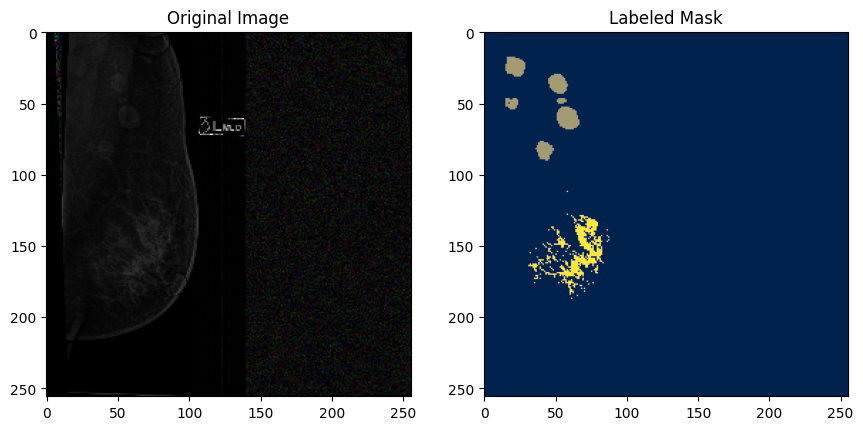

In [4]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Get a random batch index from the generator
batch_index = random.randint(0, len(test_generator) - 1)

# Access the specific batch
test_images, test_masks = test_generator[batch_index]

# Choose a random index from the batch
random_index = random.randint(0, test_images.shape[0] - 1)

# Extract the randomly chosen image and corresponding mask
test_img = test_images[random_index]
ground_truth = test_masks[random_index]

# Check the shape of the mask before one-hot encoding
print("Ground truth mask shape (after generator but before one-hot encoding):", ground_truth.shape)
print("Unique values in the mask (should be class labels):", np.unique(np.argmax(ground_truth, axis=-1)))

# Plotting
plt.figure(figsize=(16, 12))

# Plot the original image
plt.subplot(231)
plt.title('Original Image')
plt.imshow(test_img)  # Display the color image (RGB)

# Plot the labeled mask (ground truth)
plt.subplot(232)
plt.title('Labeled Mask')

# Convert one-hot encoded mask back to class labels
mask_classes = np.argmax(ground_truth, axis=-1)
plt.imshow(mask_classes, cmap='cividis')

plt.show()


In [5]:
# Example: Get a batch of images and masks from the generator
train_images, train_masks = train_generator[0]

# Now, you can get the height, width, and channels from the train_images
IMG_HEIGHT = train_images.shape[1]
IMG_WIDTH = train_images.shape[2]
IMG_CHANNELS = train_images.shape[3]  # Assuming your images are in RGB format (i.e., 3 channels)

In [6]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, concatenate, Conv2DTranspose, BatchNormalization, Activation, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import glorot_uniform

def upsample_block(x, filters, kernel_size=(3, 3), padding='same', strides=1):
    x = Conv2DTranspose(filters, kernel_size, padding=padding, strides=strides)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)  # LeakyReLU activation
    return x

def multi_unet_model2(n_classes=5, IMG_HEIGHT=256, IMG_WIDTH=256, IMG_CHANNELS=1):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    s = inputs

    # Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(s)
    c1 = BatchNormalization()(c1)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(p4)
    c5 = BatchNormalization()(c5)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c5)

    # Extra layer with 512 channels (bottleneck)
    c6 = Conv2D(512, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c5)
    c6 = BatchNormalization()(c6)
    c6 = Dropout(0.3)(c6)
    c6 = Conv2D(512, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c6)

    # Expansive path
    u6 = upsample_block(c6, 256, strides=(2, 2))
    u6 = concatenate([u6, c4])
    c7 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(u6)
    c7 = BatchNormalization()(c7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c7)

    u7 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u7 = concatenate([u7, c3])
    c8 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(u7)
    c8 = BatchNormalization()(c8)
    c8 = Dropout(0.2)(c8)
    c8 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c8)

    u8 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u8 = concatenate([u8, c2])
    c9 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(u8)
    c9 = BatchNormalization()(c9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c9)

    u9 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c9)
    u9 = concatenate([u9, c1], axis=3)
    c10 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(u9)
    c10 = BatchNormalization()(c10)
    c10 = Dropout(0.1)(c10)
    c10 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c10)

    outputs = Conv2D(n_classes, (1, 1), activation='softmax')(c10)

    # Create the full segmentation model
    model = Model(inputs=[inputs], outputs=[outputs])

    # Create a secondary model for feature extraction
    feature_extractor = Model(inputs=[inputs], outputs=[c6])  # Extract features from the bottleneck layer

    return model, feature_extractor


segmentation_model, feature_extractor = multi_unet_model2(n_classes, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS) 


/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [7]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, concatenate, Conv2DTranspose, BatchNormalization, Activation, LeakyReLU, Multiply, Add, GlobalAveragePooling2D, Reshape, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import glorot_uniform

def attention_block(x, g, inter_channel):
    theta_x = Conv2D(inter_channel, (1, 1), strides=(1, 1))(x)
    phi_g = Conv2D(inter_channel, (1, 1), strides=(1, 1))(g)
    f = Activation('relu')(Add()([theta_x, phi_g]))
    psi_f = Conv2D(1, (1, 1), strides=(1, 1))(f)
    rate = Activation('sigmoid')(psi_f)
    att_x = Multiply()([x, rate])
    return att_x

def upsample_block(x, filters, kernel_size=(3, 3), padding='same', strides=1):
    x = Conv2DTranspose(filters, kernel_size, padding=padding, strides=strides)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)  # LeakyReLU activation
    return x

def multi_unet_model2(n_classes=5, IMG_HEIGHT=SIZE_X, IMG_WIDTH=SIZE_Y, IMG_CHANNELS=1):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    s = inputs

    # Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(s)
    c1 = BatchNormalization()(c1)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(p1)
    c2 = BatchNormalization()(c2)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(p2)
    c3 = BatchNormalization()(c3)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(p3)
    c4 = BatchNormalization()(c4)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(p4)
    c5 = BatchNormalization()(c5)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c5)

    # Extra layer with 512 channels (bottleneck)
    c6 = Conv2D(512, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c5)
    c6 = BatchNormalization()(c6)
    c6 = Dropout(0.3)(c6)
    c6 = Conv2D(512, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c6)

    # Expansive path with attention gates
    u6 = upsample_block(c6, 256, strides=(2, 2))
    att6 = attention_block(c4, u6, 128)
    u6 = concatenate([u6, att6])
    c7 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(u6)
    c7 = BatchNormalization()(c7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(256, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c7)

    u7 = upsample_block(c7, 128, strides=(2, 2))
    att7 = attention_block(c3, u7, 64)
    u7 = concatenate([u7, att7])
    c8 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(u7)
    c8 = BatchNormalization()(c8)
    c8 = Dropout(0.2)(c8)
    c8 = Conv2D(128, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c8)

    u8 = upsample_block(c8, 64, strides=(2, 2))
    att8 = attention_block(c2, u8, 32)
    u8 = concatenate([u8, att8])
    c9 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(u8)
    c9 = BatchNormalization()(c9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(64, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c9)

    u9 = upsample_block(c9, 32, strides=(2, 2))
    att9 = attention_block(c1, u9, 16)
    u9 = concatenate([u9, att9])
    c10 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(u9)
    c10 = BatchNormalization()(c10)
    c10 = Dropout(0.1)(c10)
    c10 = Conv2D(32, (3, 3), activation='relu', kernel_initializer=glorot_uniform(), padding='same')(c10)

    outputs = Conv2D(n_classes, (1, 1), activation='softmax')(c10)

    # Create the full segmentation model
    model = Model(inputs=[inputs], outputs=[outputs])

    # Create a secondary model for feature extraction
    feature_extractor = Model(inputs=[inputs], outputs=[c6])  # Extract features from the bottleneck layer

    return model, feature_extractor

segmentation_model, feature_extractor = multi_unet_model2(n_classes, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

In [8]:
import keras.backend as K
import tensorflow as tf
import numpy as np
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Dropout, concatenate, Conv2DTranspose
from keras.metrics import binary_accuracy



import tensorflow as tf

def focal_loss(y_true, y_pred, gamma=2.0):
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
    cross_entropy = -y_true * tf.math.log(y_pred)


    loss = tf.pow(1 - y_pred, gamma) * cross_entropy
    return tf.reduce_mean(loss, axis=-1)


def soft_dice_coefficient(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)  # Ensure y_true is float32
    y_pred = tf.cast(y_pred, tf.float32)  # Ensure y_pred is float32
    intersection = tf.reduce_sum(y_true * y_pred, axis=(1, 2, 3))
    sum_true = tf.reduce_sum(y_true, axis=(1, 2, 3))
    sum_pred = tf.reduce_sum(y_pred, axis=(1, 2, 3))
    dice_coefficient = (2. * intersection + smooth) / (sum_true + sum_pred + smooth)
    return tf.reduce_mean(dice_coefficient)


def soft_dice_loss(y_true, y_pred, smooth=1):
    intersection = tf.reduce_sum(y_true * y_pred, axis=(1, 2, 3))
    sum_true = tf.reduce_sum(y_true, axis=(1, 2, 3))
    sum_pred = tf.reduce_sum(y_pred, axis=(1, 2, 3))
    dice_coefficient = (2. * intersection + smooth) / (sum_true + sum_pred + smooth)
    dice_loss = 1 - dice_coefficient
    return tf.reduce_mean(dice_loss)



def combined_loss(y_true, y_pred, gamma=2.0, alpha=0.5):
    focal = focal_loss(y_true, y_pred, gamma)
    dice = soft_dice_loss(y_true, y_pred)
    return alpha * focal + (1 - alpha) * dice


import tensorflow as tf


class CustomMeanIoU(tf.keras.metrics.MeanIoU):
   
    def __init__(self, num_classes=None, name=None, dtype=None):
        super(CustomMeanIoU, self).__init__(
            num_classes=num_classes, name=name, dtype=dtype
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.math.argmax(y_true, axis=-1)
        y_pred = tf.math.argmax(y_pred, axis=-1)
        return super().update_state(y_true, y_pred, sample_weight)
    
custom_mIoU_metric = CustomMeanIoU(num_classes=5, name='mean_iou')

In [9]:
## Compile the model
segmentation_model.compile(optimizer=Adam(learning_rate=0.001), loss=combined_loss, metrics=['accuracy', soft_dice_coefficient, custom_mIoU_metric])
# Print model summary
segmentation_model.summary()



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 256, 256, 16)   │            448 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_11    │ (None, 256, 256, 16)   │             64 │ conv2d_21[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_10 (Dropout)      │ (None, 256, 256, 16)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_22 (Conv2D)        │ (None, 256, 256, 16)   │          2,320 │ dropout_10[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 128, 128, 16)   │              0 │ conv2d_22[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 128, 128, 32)   │          4,640 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_12    │ (None, 128, 128, 32)   │            128 │ conv2d_23[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_11 (Dropout)      │ (None, 128, 128, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 128, 128, 32)   │          9,248 │ dropout_11[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_5           │ (None, 64, 64, 32)     │              0 │ conv2d_24[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_25 (Conv2D)        │ (None, 64, 64, 64)     │         18,496 │ max_pooling2d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_13    │ (None, 64, 64, 64)     │            256 │ conv2d_25[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_12 (Dropout)      │ (None, 64, 64, 64)     │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_26 (Conv2D)        │ (None, 64, 64, 64)     │         36,928 │ dropout_12[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 32, 32, 64)     │              0 │ conv2d_26[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├──────────────────────

 Total params: 8,319,337 (31.74 MB)

 Trainable params: 8,315,401 (31.72 MB)

 Non-trainable params: 3,936 (15.38 KB)

In [ ]:
# Define Early Stopping and Model Checkpoint
early_stopping = EarlyStopping(monitor='val_mean_iou', patience=40, mode='max', restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model1_t1_600Epochs.keras', monitor='val_mean_iou', mode='max', save_best_only=True)

# Train the model
history = segmentation_model.fit(
    train_generator,
    verbose=1,
    epochs=100,
    validation_data=test_generator,
    callbacks=[early_stopping, model_checkpoint],
    shuffle=False
)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


151/151 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9416 - loss: 0.0722 - mean_iou: 0.1522 - soft_dice_coefficient: 0.8850 - val_accuracy: 0.9618 - val_loss: 0.0461 - val_mean_iou: 0.1852 - val_soft_dice_coefficient: 0.9597
Epoch 2/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 107s 708ms/step - accuracy: 0.9712 - loss: 0.0246 - mean_iou: 0.2324 - soft_dice_coefficient: 0.9652 - val_accuracy: 0.9618 - val_loss: 0.0587 - val_mean_iou: 0.1852 - val_soft_dice_coefficient: 0.9618
Epoch 3/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 104s 686ms/step - accuracy: 0.9738 - loss: 0.0219 - mean_iou: 0.2674 - soft_dice_coefficient: 0.9686 - val_accuracy: 0.9618 - val_loss: 0.0566 - val_mean_iou: 0.1852 - val_soft_dice_coefficient: 0.9618
Epoch 4/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 108s 711ms/step - accuracy: 0.9752 - loss: 0.0204 - mean_iou: 0.3170 - soft_dice_coefficient: 0.9704 - val_accuracy: 0.9666 - val_loss: 0.0302 - val_mean_iou: 0.2400 - val_soft_dice_coefficient: 0.9663
Epoch 5/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 10

In [ ]:
# Define Early Stopping to monitor 'val_dice_coefficient' and restore the best weights
early_stopping = EarlyStopping(monitor='val_mean_iou', patience=100, mode='max', restore_best_weights=True)

# Define Model Checkpoint to save the best model based on 'val_dice_coefficient'
model_checkpoint = ModelCheckpoint('saved_model1_t2_resized_v2_Kaggle_200eo_gamma_2_alpha_0.5_B8_MODEL_SAN.keras', monitor='val_mean_iou', mode='max', save_best_only=True)

from keras.callbacks import LearningRateScheduler

# Define the learning rate schedule function
def lr_schedule(epoch):
    initial_lr = 0.001
    return initial_lr * (0.5 ** (epoch // 10))  # Reducing LR by half every 10 epochs

# Create the learning rate scheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)

from keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_mean_iou', factor=0.5, patience=100, min_lr=1e-6)

# Train the model
history = segmentation_model.fit(
    train_generator,
    verbose=1,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stopping, model_checkpoint, reduce_lr,lr_scheduler],
    shuffle=False
)

Ground truth mask shape (after generator but before one-hot encoding): (256, 256, 5)
Unique values in the mask (should be class labels): [0 1 3 4]


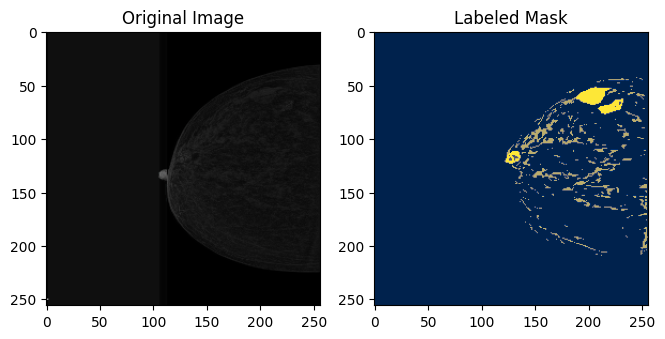

In [13]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Get a random batch index from the generator
batch_index = random.randint(0, len(test_generator) - 1)

# Access the specific batch
test_images, test_masks = test_generator[batch_index]

# Choose a random index from the batch
random_index = random.randint(0, test_images.shape[0] - 1)

# Extract the randomly chosen image and corresponding mask
test_img = test_images[random_index]
ground_truth = test_masks[random_index]

# Check the shape of the mask before one-hot encoding
print("Ground truth mask shape (after generator but before one-hot encoding):", ground_truth.shape)
print("Unique values in the mask (should be class labels):", np.unique(np.argmax(ground_truth, axis=-1)))

# Plotting
plt.figure(figsize=(12, 8))

# Plot the original image
plt.subplot(231)
plt.title('Original Image')
plt.imshow(test_img)  # Display the color image (RGB)

# Plot the labeled mask (ground truth)
plt.subplot(232)
plt.title('Labeled Mask')

# Convert one-hot encoded mask back to class labels
mask_classes = np.argmax(ground_truth, axis=-1)
plt.imshow(mask_classes, cmap='cividis')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Ground truth mask shape (after generator but before one-hot encoding): (256, 256, 5)
Unique values in the mask (should be class labels): [0 3 4]
Unique values in the predicted mask (should be class labels): [0 3 4]


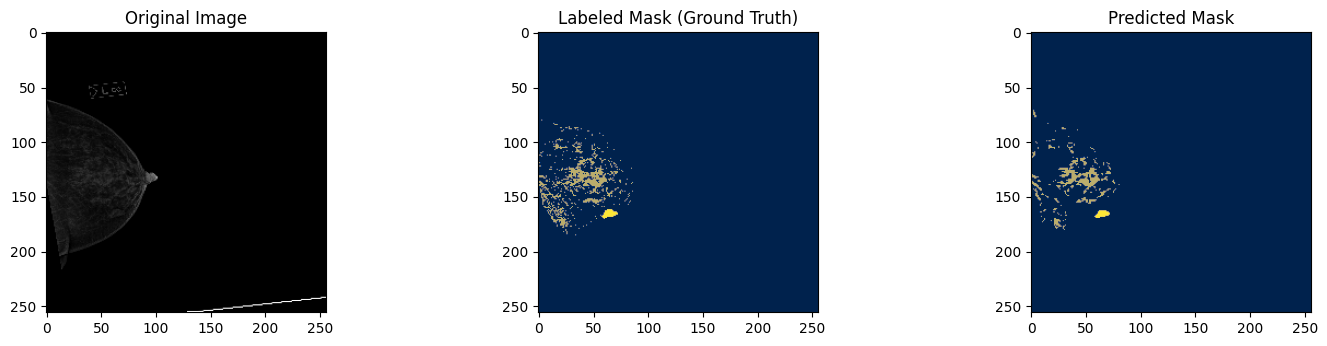

In [21]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Get a random batch index from the generator
batch_index = random.randint(0, len(test_generator) - 1)

# Access the specific batch
test_images, test_masks = test_generator[batch_index]

# Choose a random index from the batch
random_index = random.randint(0, test_images.shape[0] - 1)

# Extract the randomly chosen image and corresponding mask
test_img = test_images[random_index]
ground_truth = test_masks[random_index]

# Predict the mask for the test image using the trained model
predicted_mask = segmentation_model.predict(np.expand_dims(test_img, axis=0))  # Predict for one image

# Convert the predicted mask from one-hot encoding to class labels
predicted_mask_class = np.argmax(predicted_mask, axis=-1)[0]  # Squeeze extra dimensions

# Check the shape of the mask before one-hot encoding
print("Ground truth mask shape (after generator but before one-hot encoding):", ground_truth.shape)
print("Unique values in the mask (should be class labels):", np.unique(np.argmax(ground_truth, axis=-1)))
print("Unique values in the predicted mask (should be class labels):", np.unique(predicted_mask_class))

# Plotting
plt.figure(figsize=(18, 8))

# Plot the original image
plt.subplot(231)
plt.title('Original Image')
plt.imshow(test_img)  # Display the color image (RGB)

# Plot the labeled mask (ground truth)
plt.subplot(232)
plt.title('Labeled Mask (Ground Truth)')

# Convert one-hot encoded mask back to class labels
mask_classes = np.argmax(ground_truth, axis=-1)
plt.imshow(mask_classes, cmap='cividis')

# Plot the predicted mask
plt.subplot(233)
plt.title('Predicted Mask')
plt.imshow(predicted_mask_class, cmap='cividis')

plt.show()


In [ ]:
import numpy as np
from keras.metrics import MeanIoU

# Number of classes in your segmentation problem
n_classes = 5

# Initialize MeanIoU metric
iou_metric = MeanIoU(num_classes=n_classes)

# Loop through the test generator to get all the batches
for batch_index in range(len(test_generator)):
    # Get a batch of test images and masks
    test_images, test_masks = test_generator[batch_index]

    # Predict the mask for the batch of test images
    y_pred = segmentation_model.predict(test_images)
    
    # Convert predictions to class labels (argmax)
    y_pred_argmax = np.argmax(y_pred, axis=-1)  # Assuming the last dimension is for class probabilities
    
    # Convert the test masks from one-hot encoded to class labels
    y_true = np.argmax(test_masks, axis=-1)
    
    # Update the IoU metric with the true and predicted masks for the current batch
    iou_metric.update_state(y_true, y_pred_argmax)

# Print the Mean IoU across all batches
mean_iou = iou_metric.result().numpy()
print("Mean IoU =", mean_iou)

In [22]:
#### UPDATED ###############
import numpy as np
from keras.metrics import MeanIoU

# Number of classes in your segmentation problem
n_classes = 5

# Initialize MeanIoU metric
iou_metric = MeanIoU(num_classes=n_classes)

# Initialize accumulators for per-class IoU calculation
iou_classes = {i: {'intersection': 0, 'union': 0} for i in range(n_classes)}

# Loop through the test generator to get all the batches
for batch_index in range(len(test_generator)):
    # Get a batch of test images and masks
    test_images, test_masks = test_generator[batch_index]

    # Predict the mask for the batch of test images
    y_pred = segmentation_model.predict(test_images)
    
    # Convert predictions to class labels (argmax)
    y_pred_argmax = np.argmax(y_pred, axis=-1)  # Assuming the last dimension is for class probabilities
    
    # Convert the test masks from one-hot encoded to class labels
    y_true = np.argmax(test_masks, axis=-1)
    
    # Update the IoU metric with the true and predicted masks for the current batch
    iou_metric.update_state(y_true, y_pred_argmax)

    # Accumulate intersection and union for each class
    for i in range(n_classes):
        intersection = np.logical_and(y_true == i, y_pred_argmax == i).sum()
        union = np.logical_or(y_true == i, y_pred_argmax == i).sum()
        iou_classes[i]['intersection'] += intersection
        iou_classes[i]['union'] += union

# Print the Mean IoU across all batches
mean_iou = iou_metric.result().numpy()
print("Mean IoU =", mean_iou)

# Calculate final IoU for each class
class_iou = {}
for i in range(n_classes):
    intersection = iou_classes[i]['intersection']
    union = iou_classes[i]['union']
    if union == 0:
        iou = 1.0  # If no ground truth or predicted pixels for this class, set IoU to 1
    else:
        iou = intersection / union
    class_iou[i] = iou

print("IoU for each class:", class_iou)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Mean IoU = 0.76838654
IoU for each class: {0: 0.9847671864077279, 1: 0.6711711711711712, 2: 0.7093864693383259, 3: 0.6130406386177761, 4: 0.863567294394837}


In [23]:
from sklearn.metrics import f1_score

# Initialize accumulators for per-class Dice Coefficient
dice_classes = {i: {'numerator': 0, 'denominator': 0} for i in range(n_classes)}

# Loop through the test generator to get all the batches
for batch_index in range(len(test_generator)):
    # Get a batch of test images and masks
    test_images, test_masks = test_generator[batch_index]

    # Predict the mask for the batch of test images
    y_pred = segmentation_model.predict(test_images)
    
    # Convert predictions to class labels (argmax)
    y_pred_argmax = np.argmax(y_pred, axis=-1)  # Assuming the last dimension is for class probabilities
    
    # Convert the test masks from one-hot encoded to class labels
    y_true = np.argmax(test_masks, axis=-1)
    
    # Calculate Dice Coefficient for each class
    for i in range(n_classes):
        y_true_class = (y_true == i).astype(int)
        y_pred_class = (y_pred_argmax == i).astype(int)
        
        # Dice Coefficient = 2 * |A ∩ B| / (|A| + |B|)
        numerator = 2 * np.sum(y_true_class * y_pred_class)
        denominator = np.sum(y_true_class) + np.sum(y_pred_class)
        
        dice_classes[i]['numerator'] += numerator
        dice_classes[i]['denominator'] += denominator

# Calculate final Dice Coefficient for each class
class_dice = {}
for i in range(n_classes):
    numerator = dice_classes[i]['numerator']
    denominator = dice_classes[i]['denominator']
    if denominator == 0:
        dice = 1.0  # If no ground truth or predicted pixels for this class, set Dice to 1
    else:
        dice = numerator / denominator
    class_dice[i] = dice

print("Dice Coefficient for each class:", class_dice)
print("Average Dice Coefficient:", np.mean(list(class_dice.values())))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Dice Coefficient for each class: {0: 0.9923251383353217, 1: 0.8032345013477089, 2: 0.8299895688456189, 3: 0.7601056339697606, 4: 0.9267894934540224}
Average Dice Coefficient: 0.8624888671904865


In [19]:
from scipy.ndimage import distance_transform_edt

def calculate_surface_distances(y_true, y_pred):
    """
    Calculate surface distances between the true and predicted masks.
    
    Args:
        y_true: Ground truth mask (2D array of class indices).
        y_pred: Predicted mask (2D array of class indices).
        
    Returns:
        surface_distances: List of surface distances for each class.
    """
    surface_distances = []
    for i in range(n_classes):
        y_true_class = (y_true == i).astype(int)
        y_pred_class = (y_pred == i).astype(int)
        
        # Calculate distance transforms
        dist_true = distance_transform_edt(1 - y_true_class)
        dist_pred = distance_transform_edt(1 - y_pred_class)
        
        # Surface distances
        surface_distances.append((dist_true[y_pred_class == 1].sum() + dist_pred[y_true_class == 1].sum()) /
                                 (y_true_class.sum() + y_pred_class.sum()))
    return surface_distances

# Initialize accumulators for per-class ASD and NSD
asd_classes = {i: 0 for i in range(n_classes)}
nsd_classes = {i: 0 for i in range(n_classes)}

# Loop through the test generator to get all the batches
for batch_index in range(len(test_generator)):
    # Get a batch of test images and masks
    test_images, test_masks = test_generator[batch_index]

    # Predict the mask for the batch of test images
    y_pred = segmentation_model.predict(test_images)
    
    # Convert predictions to class labels (argmax)
    y_pred_argmax = np.argmax(y_pred, axis=-1)  # Assuming the last dimension is for class probabilities
    
    # Convert the test masks from one-hot encoded to class labels
    y_true = np.argmax(test_masks, axis=-1)
    
    # Calculate ASD and NSD for each class
    surface_distances = calculate_surface_distances(y_true, y_pred_argmax)
    for i in range(n_classes):
        asd_classes[i] += surface_distances[i]
        nsd_classes[i] += surface_distances[i] / np.max(surface_distances)  # Normalized Surface Distance

# Calculate final ASD and NSD for each class
class_asd = {i: asd_classes[i] / len(test_generator) for i in range(n_classes)}
class_nsd = {i: nsd_classes[i] / len(test_generator) for i in range(n_classes)}

print("Average Surface Distance (ASD) for each class:", class_asd)
print("Average ASD:", np.mean(list(class_asd.values())))
print("Normalized Surface Distance (NSD) for each class:", class_nsd)
print("Average NSD:", np.mean(list(class_nsd.values())))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Average Surface Distance (ASD) for each class: {0: 0.00833380594880232, 1: 18.096055454683807, 2: 1.1855808359278388, 3: 0.43207564175018837, 4: 0.6301114185912388}
Average ASD: 4.070431431380374
Normalized Surface Distance (NSD) for each class: {0: 0.001233418286045765, 1: 0.9700455804251026, 2: 0.17556821955724608, 3: 0.07527135636898365, 4: 0.133117

In [ ]:
from scipy.spatial.distance import directed_hausdorff

def calculate_hausdorff_distance(y_true, y_pred):
    """
    Calculate Hausdorff Distance between the true and predicted masks.
    
    Args:
        y_true: Ground truth mask (2D array of class indices).
        y_pred: Predicted mask (2D array of class indices).
        
    Returns:
        hausdorff_distances: List of Hausdorff distances for each class.
    """
    hausdorff_distances = []
    for i in range(n_classes):
        y_true_class = (y_true == i).astype(int)
        y_pred_class = (y_pred == i).astype(int)
        
        # Get coordinates of the surface points
        true_coords = np.column_stack(np.where(y_true_class == 1))
        pred_coords = np.column_stack(np.where(y_pred_class == 1))
        
        # Calculate Hausdorff Distance
        if true_coords.size == 0 or pred_coords.size == 0:
            hausdorff_distances.append(0)  # If no surface points, set distance to 0
        else:
            hausdorff_distances.append(max(directed_hausdorff(true_coords, pred_coords)[0],
                                          directed_hausdorff(pred_coords, true_coords)[0]))
    return hausdorff_distances

# Initialize accumulators for per-class Hausdorff Distance
hausdorff_classes = {i: 0 for i in range(n_classes)}

# Loop through the test generator to get all the batches
for batch_index in range(len(test_generator)):
    # Get a batch of test images and masks
    test_images, test_masks = test_generator[batch_index]

    # Predict the mask for the batch of test images
    y_pred = segmentation_model.predict(test_images)
    
    # Convert predictions to class labels (argmax)
    y_pred_argmax = np.argmax(y_pred, axis=-1)  # Assuming the last dimension is for class probabilities
    
    # Convert the test masks from one-hot encoded to class labels
    y_true = np.argmax(test_masks, axis=-1)
    
    # Calculate Hausdorff Distance for each class
    hausdorff_distances = calculate_hausdorff_distance(y_true, y_pred_argmax)
    for i in range(n_classes):
        hausdorff_classes[i] += hausdorff_distances[i]

# Calculate final Hausdorff Distance for each class
class_hausdorff = {i: hausdorff_classes[i] / len(test_generator) for i in range(n_classes)}

print("Hausdorff Distance for each class:", class_hausdorff)
print("Average Hausdorff Distance:", np.mean(list(class_hausdorff.values())))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Unique values in the ground truth mask (should be class labels): [0 2 3]
Unique values in the predicted mask (should be class labels): [0 2 3]


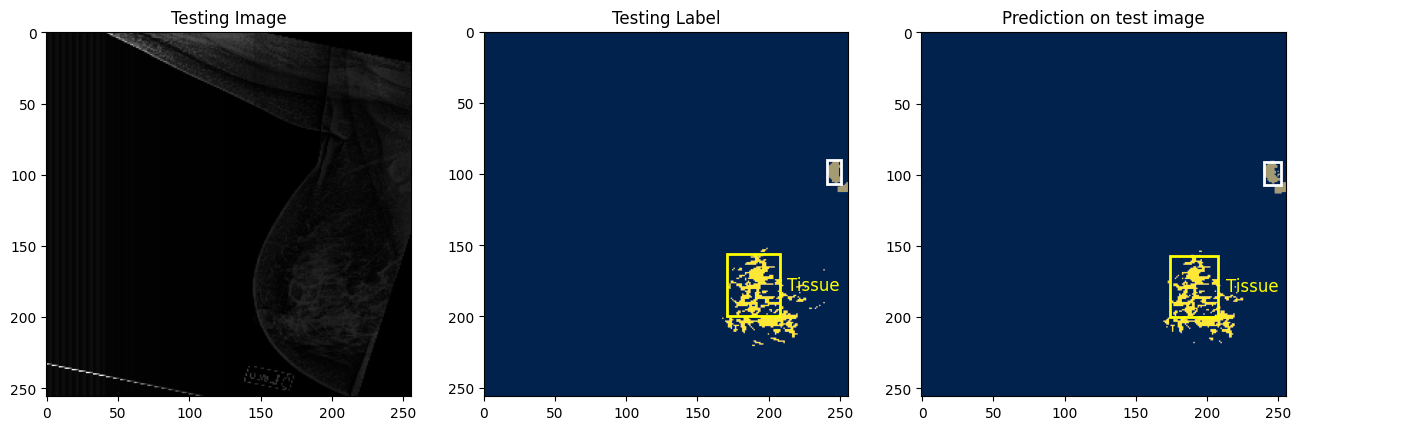

In [22]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

# Define the threshold for bounding box detection (if needed)
threshold = 0.2

# Select a random batch from the test generator
batch_index = random.randint(0, len(test_generator) - 1)
test_images, test_masks = test_generator[batch_index]

# Select a random image from the batch
random_index = random.randint(0, test_images.shape[0] - 1)
test_img = test_images[random_index]
ground_truth = test_masks[random_index]

# Normalize or adjust the test image if needed (assuming it's grayscale)
test_img_norm = test_img[:, :, 0]  # Assuming it's a grayscale image

# Make prediction for the selected test image
prediction = segmentation_model.predict(np.expand_dims(test_img, axis=0))  # Add batch dimension
predicted_img = np.argmax(prediction, axis=-1)[0]  # Get the class labels from prediction (remove batch dim)

# Define class names and corresponding colors
class_names = ['Background', 'Calcification', 'Axilla_Findings', 'Tissue', 'Mass']
colors = ['black', 'orange', 'white', 'yellow', 'red']  # Define a color for each class

# Check unique values in masks for debugging
# For ground truth, use np.argmax to convert one-hot encoded masks to class labels
ground_truth_labels = np.argmax(ground_truth, axis=-1)

# For predicted mask, we already have class labels in predicted_img
print("Unique values in the ground truth mask (should be class labels):", np.unique(ground_truth_labels))
print("Unique values in the predicted mask (should be class labels):", np.unique(predicted_img))

# Plotting
plt.figure(figsize=(16, 12))

# Plot the grayscale test image
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img_norm, cmap='gray')

# Plot the ground truth mask
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth_labels, cmap='cividis', extent=(0, ground_truth.shape[1], ground_truth.shape[0], 0))

# Plot the predicted mask
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(predicted_img, cmap='cividis')

# Function to add bounding boxes for given masks
def add_bounding_boxes(mask, colors, class_names):
    for class_index in range(1, len(class_names)):  # Skip 'Background' class (index 0)
        # Find contours for the current class in the provided mask
        contours, _ = cv2.findContours(np.uint8(mask == class_index), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # If contours are found for the current class
        if contours:
            # Get the largest contour by area
            contour = max(contours, key=cv2.contourArea)
            # Get bounding box coordinates
            x, y, w, h = cv2.boundingRect(contour)
            # Choose the color for the current class
            box_color = colors[class_index]
            # Draw bounding box
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=box_color, facecolor='none')
            plt.gca().add_patch(rect)
            # Add class name near the bounding box
            class_name = class_names[class_index]
            text_x = x + w + 5  # Offset the text slightly to the right
            text_y = y + h // 2  # Center the text vertically in the box
            plt.text(text_x, text_y, class_name, color=box_color, fontsize=12, verticalalignment='center')

# Add bounding boxes for the ground truth mask
plt.subplot(232)  # Go to the ground truth subplot
add_bounding_boxes(ground_truth_labels, colors, class_names)

# Add bounding boxes for the predicted mask
plt.subplot(233)  # Go to the predicted mask subplot
add_bounding_boxes(predicted_img, colors, class_names)

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Unique values in the ground truth mask (should be class labels): [0 2 3]
Unique values in the predicted mask (should be class labels): [0 2 3]

IoU for each class:
Background: 0.9915
Calcification: 0.0000
Axilla_Findings: 0.3788
Tissue: 0.7425
Mass: 0.0000

Mean IoU (excluding background): 0.2803


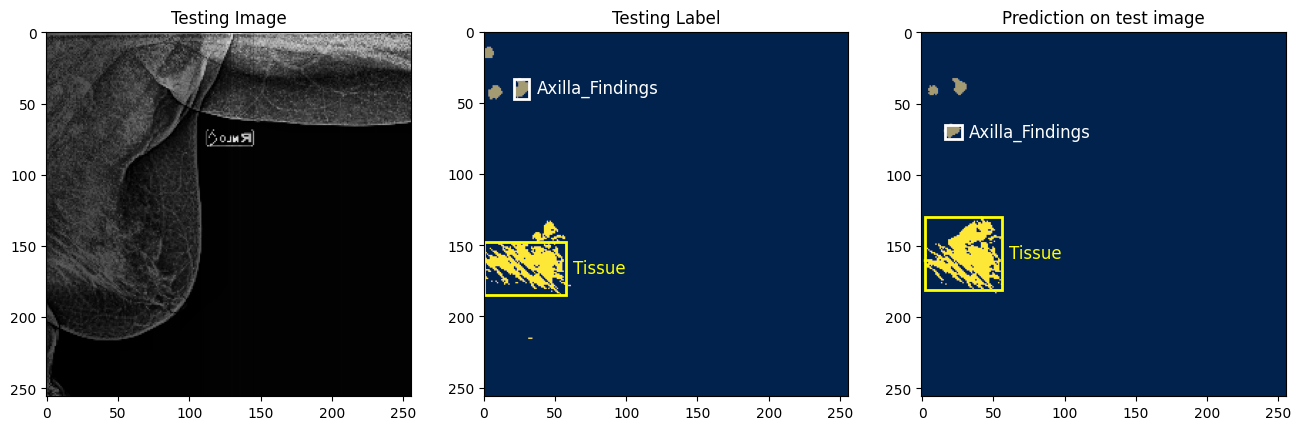

In [23]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

# Define the threshold for bounding box detection (if needed)
threshold = 0.2

# Select a random batch from the test generator
batch_index = random.randint(0, len(test_generator) - 1)
test_images, test_masks = test_generator[batch_index]

# Select a random image from the batch
random_index = random.randint(0, test_images.shape[0] - 1)
test_img = test_images[random_index]
ground_truth = test_masks[random_index]

# Normalize or adjust the test image if needed (assuming it's grayscale)
test_img_norm = test_img[:, :, 0]  # Assuming it's a grayscale image

# Make prediction for the selected test image
prediction = segmentation_model.predict(np.expand_dims(test_img, axis=0))  # Add batch dimension
predicted_img = np.argmax(prediction, axis=-1)[0]  # Get the class labels from prediction (remove batch dim)

# Define class names and corresponding colors
class_names = ['Background', 'Calcification', 'Axilla_Findings', 'Tissue', 'Mass']
colors = ['black', 'orange', 'white', 'yellow', 'red']  # Define a color for each class

# Check unique values in masks for debugging
# For ground truth, use np.argmax to convert one-hot encoded masks to class labels
ground_truth_labels = np.argmax(ground_truth, axis=-1)

# For predicted mask, we already have class labels in predicted_img
print("Unique values in the ground truth mask (should be class labels):", np.unique(ground_truth_labels))
print("Unique values in the predicted mask (should be class labels):", np.unique(predicted_img))

# Function to calculate IoU for each class
def calculate_iou(y_true, y_pred, num_classes):
    iou_scores = []
    for class_index in range(num_classes):
        # Create binary masks for the current class
        true_class = (y_true == class_index)
        pred_class = (y_pred == class_index)
        
        # Calculate intersection and union
        intersection = np.logical_and(true_class, pred_class).sum()
        union = np.logical_or(true_class, pred_class).sum()
        
        # Avoid division by zero
        if union == 0:
            iou = 0
        else:
            iou = intersection / union
        
        iou_scores.append(iou)
    return iou_scores

# Calculate IoU for each class
iou_scores = calculate_iou(ground_truth_labels, predicted_img, len(class_names))

# Calculate mean IoU (excluding the background class if needed)
mean_iou = np.mean(iou_scores[1:])  # Exclude background (class 0)

# Print IoU for each class and mean IoU
print("\nIoU for each class:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {iou_scores[i]:.4f}")
print(f"\nMean IoU (excluding background): {mean_iou:.4f}")

# Plotting
plt.figure(figsize=(16, 12))

# Plot the grayscale test image
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img_norm, cmap='gray')

# Plot the ground truth mask
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth_labels, cmap='cividis', extent=(0, ground_truth.shape[1], ground_truth.shape[0], 0))

# Plot the predicted mask
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(predicted_img, cmap='cividis')

# Function to add bounding boxes for given masks
def add_bounding_boxes(mask, colors, class_names):
    for class_index in range(1, len(class_names)):  # Skip 'Background' class (index 0)
        # Find contours for the current class in the provided mask
        contours, _ = cv2.findContours(np.uint8(mask == class_index), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # If contours are found for the current class
        if contours:
            # Get the largest contour by area
            contour = max(contours, key=cv2.contourArea)
            # Get bounding box coordinates
            x, y, w, h = cv2.boundingRect(contour)
            # Choose the color for the current class
            box_color = colors[class_index]
            # Draw bounding box
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=box_color, facecolor='none')
            plt.gca().add_patch(rect)
            # Add class name near the bounding box
            class_name = class_names[class_index]
            text_x = x + w + 5  # Offset the text slightly to the right
            text_y = y + h // 2  # Center the text vertically in the box
            plt.text(text_x, text_y, class_name, color=box_color, fontsize=12, verticalalignment='center')

# Add bounding boxes for the ground truth mask
plt.subplot(232)  # Go to the ground truth subplot
add_bounding_boxes(ground_truth_labels, colors, class_names)

# Add bounding boxes for the predicted mask
plt.subplot(233)  # Go to the predicted mask subplot
add_bounding_boxes(predicted_img, colors, class_names)

plt.show()

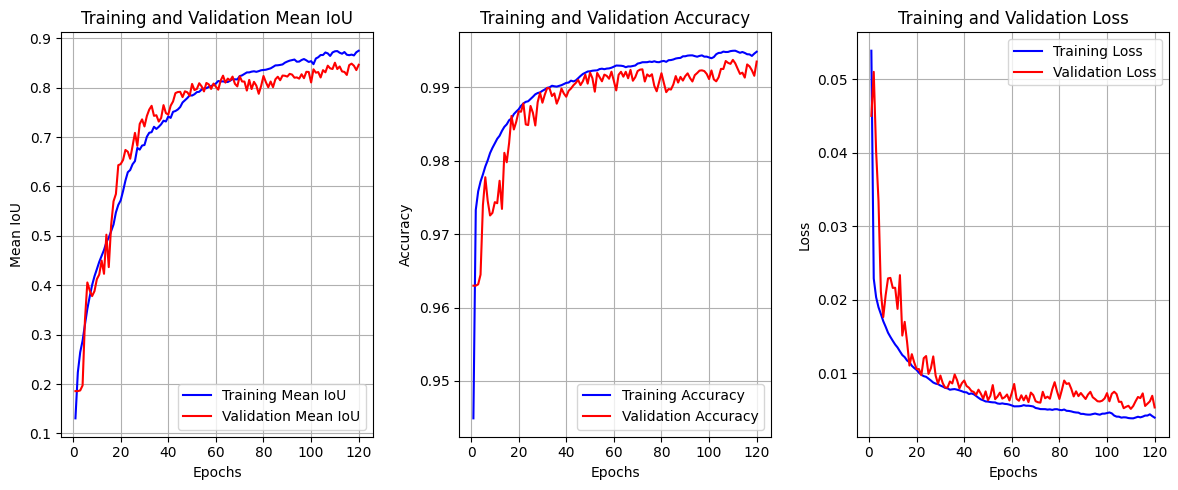

In [24]:
import matplotlib.pyplot as plt

# Extract metrics from history
train_iou = history.history['mean_iou']
val_iou = history.history['val_mean_iou']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_iou) + 1)

# Plot Mean IoU
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.plot(epochs, train_iou, 'b', label='Training Mean IoU')
plt.plot(epochs, val_iou, 'r', label='Validation Mean IoU')
plt.title('Training and Validation Mean IoU')
plt.xlabel('Epochs')
plt.ylabel('Mean IoU')
plt.legend()
plt.grid()

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Plot Loss
plt.subplot(1, 3, 3)
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ======================== Step 1: Load and Preprocess Data ========================

# Load the Excel file
file_path = '/kaggle/input/multimodal-merged-aug-set-1-3-report-only/report/multimodal_merged_set_1_2_3_BIRADS_revised_aug_filled_done.xlsx'
data = pd.read_excel(file_path)

# Split the dataset into training and testing sets (10% test size) with a fixed random state
train_data, test_data = train_test_split(data, test_size=0.10, random_state=0)

# Sort the train_data and test_data A-Z in terms of image_id
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)


# # Sort the train_data and test_data A-Z in terms of image_id
# train_data = train_data.sort_values(by='image_id').reset_index(drop=True)
# test_data = test_data.sort_values(by='image_id').reset_index(drop=True)


train_data.head()
#test_data.head()
  

,image_id,mass,mass_definition,mass_density,mass_shape,mass_calcification,axilla_findings,calcification,calcification_type,acr_breast_density,BIRADS_CAT
0,2408203832_240828_BREAST_0867_AH06421999,0,0,0,0,0,1,0,0,4,2
1,IMG184_aug_154_1187,1,1,2,3,0,0,0,0,2,3
2,2407176350_240717_BREAST_1121_AH06421999_aug_1...,0,0,0,0,0,1,0,0,2,2
3,IMG284_aug_154_1490,1,1,1,3,0,0,0,0,2,4
4,2401051537_240207_BREAST_2139_AH06421999_aug_1...,0,0,0,0,0,0,1,1,1,2


In [26]:
# Extract image IDs from the filenames
train_mask_image_ids = [os.path.splitext(filename)[0] for filename in train_mask_filenames[:5]]
test_image_image_ids = [os.path.splitext(filename)[0] for filename in test_image_filenames[:5]]

# Extract image IDs from the train_data and test_data
train_data_image_ids = train_data['image_id'].astype(str).head(5).tolist()
test_data_image_ids = test_data['image_id'].astype(str).head(5).tolist()

# Check if the image IDs match
train_match = train_mask_image_ids == train_data_image_ids
test_match = test_image_image_ids == test_data_image_ids

# Print results
print("Do the first 5 training mask filenames match train_data image IDs?", train_match)
print("Training mask filenames:", train_mask_image_ids)
print("Train_data image IDs:", train_data_image_ids)

print("\nDo the first 5 testing image filenames match test_data image IDs?", test_match)
print("Testing image filenames:", test_image_image_ids)
print("Test_data image IDs:", test_data_image_ids)

Do the first 5 training mask filenames match train_data image IDs? True
Training mask filenames: ['2408203832_240828_BREAST_0867_AH06421999', 'IMG184_aug_154_1187', '2407176350_240717_BREAST_1121_AH06421999_aug_181_534', 'IMG284_aug_154_1490', '2401051537_240207_BREAST_2139_AH06421999_aug_181_297']
Train_data image IDs: ['2408203832_240828_BREAST_0867_AH06421999', 'IMG184_aug_154_1187', '2407176350_240717_BREAST_1121_AH06421999_aug_181_534', 'IMG284_aug_154_1490', '2401051537_240207_BREAST_2139_AH06421999_aug_181_297']

Do the first 5 testing image filenames match test_data image IDs? True
Testing image filenames: ['IMG318_aug_154_1721', '2312029720_231218_BREAST_0426_AH06421999_aug_181_77', 'IMG285_aug_181_1106', 'IMG073_aug_154_776', '2312029720_231218_BREAST_0428_AH06421999_aug_181_89']
Test_data image IDs: ['IMG318_aug_154_1721', '2312029720_231218_BREAST_0426_AH06421999_aug_181_77', 'IMG285_aug_181_1106', 'IMG073_aug_154_776', '2312029720_231218_BREAST_0428_AH06421999_aug_181_89']

In [27]:
# Drop the image_id column
train_data = train_data.drop(columns=['image_id'])
test_data = test_data.drop(columns=['image_id'])

# Display the first few rows of the training and testing data
print("Training Data:")
print(train_data.shape)

print("\nTesting Data:")
print(test_data.shape)   

Training Data:
(4831, 10)

Testing Data:
(537, 10)


In [28]:
train_data.shape

(4831, 10)

In [29]:
# All columns are target variables
target_columns = train_data.columns.tolist()

# Determine the number of unique classes for each target variable
output_dims = {col: len(train_data[col].unique()) for col in target_columns}
print("Target Variables:", target_columns)
print("Output Dimensions:", output_dims)

Target Variables: ['mass', 'mass_definition', 'mass_density', 'mass_shape', 'mass_calcification', 'axilla_findings', 'calcification', 'calcification_type', 'acr_breast_density', 'BIRADS_CAT']
Output Dimensions: {'mass': 2, 'mass_definition': 4, 'mass_density': 4, 'mass_shape': 4, 'mass_calcification': 3, 'axilla_findings': 2, 'calcification': 2, 'calcification_type': 4, 'acr_breast_density': 4, 'BIRADS_CAT': 6}


In [30]:
# Separate input (X) and outputs (y)
X_train_tabular = train_data[target_columns].copy()
X_test_tabular = test_data[target_columns].copy()

# Create dictionaries for multi-output targets
y_train_tabular = {col: train_data[col] for col in target_columns}
y_test_tabular = {col: test_data[col] for col in target_columns}

# Encode categorical labels
label_encoders = {}
for col in target_columns:
    le = LabelEncoder()
    y_train_tabular[col] = le.fit_transform(y_train_tabular[col])
    y_test_tabular[col] = le.transform(y_test_tabular[col])
    label_encoders[col] = le

for col in target_columns:
    print(f"\nColumn: {col}")
    print("Unique Values (Train):", train_data[col].unique())
    print("Unique Values (Test):", test_data[col].unique()) 


Column: mass
Unique Values (Train): [0 1]
Unique Values (Test): [1 0]

Column: mass_definition
Unique Values (Train): [0 1 2 3]
Unique Values (Test): [1 0 2 3]

Column: mass_density
Unique Values (Train): [0 2 1 3]
Unique Values (Test): [1 0 2 3]

Column: mass_shape
Unique Values (Train): [0 3 1 2]
Unique Values (Test): [3 0 2 1]

Column: mass_calcification
Unique Values (Train): [0 1 3]
Unique Values (Test): [0 1 3]

Column: axilla_findings
Unique Values (Train): [1 0]
Unique Values (Test): [0 1]

Column: calcification
Unique Values (Train): [0 1]
Unique Values (Test): [0 1]

Column: calcification_type
Unique Values (Train): [0 1 3 2]
Unique Values (Test): [0 1 2 3]

Column: acr_breast_density
Unique Values (Train): [4 2 1 3]
Unique Values (Test): [2 1 3 4]

Column: BIRADS_CAT
Unique Values (Train): [2 3 4 1 6 5]
Unique Values (Test): [3 2 4 1 6 5]


In [31]:
# Find unseen labels in the test set
for col in target_columns:
    train_unique = set(train_data[col].unique())  # Unique values in the training set
    test_unique = set(test_data[col].unique())    # Unique values in the test set
    
    # Identify unseen labels
    unseen_labels = test_unique - train_unique
    
    if unseen_labels:
        print(f"\nColumn: {col}")
        print("Unique Values (Train):", sorted(train_unique))
        print("Unique Values (Test):", sorted(test_unique))
        print("Unseen Labels:", sorted(unseen_labels))    


In [32]:
from sklearn.preprocessing import StandardScaler

# # Define segmentation data for feature extraction
# X_train_segmentation = X_train
# X_test_segmentation = X_test

# Generate segmentation features
train_features_segmentation = feature_extractor.predict(train_generator)
test_features_segmentation = feature_extractor.predict(test_generator)
print("Train Segmentation Feature Shape:", train_features_segmentation.shape)
print("Test Segmentation Feature Shape:", test_features_segmentation.shape) 


# Apply Global Average Pooling to reduce dimensions
train_features_segmentation = train_features_segmentation.reshape(len(train_features_segmentation), -1, 512).mean(axis=1)
test_features_segmentation = test_features_segmentation.reshape(len(test_features_segmentation), -1, 512).mean(axis=1)
print("Reduced Train Segmentation Feature Shape:", train_features_segmentation.shape)
print("Reduced Test Segmentation Feature Shape:", test_features_segmentation.shape) 


# Normalize segmentation features
scaler_seg = StandardScaler()
train_features_segmentation = scaler_seg.fit_transform(train_features_segmentation)
test_features_segmentation = scaler_seg.transform(test_features_segmentation)

151/151 ━━━━━━━━━━━━━━━━━━━━ 83s 544ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 539ms/step
Train Segmentation Feature Shape: (4831, 16, 16, 512)
Test Segmentation Feature Shape: (537, 16, 16, 512)
Reduced Train Segmentation Feature Shape: (4831, 512)
Reduced Test Segmentation Feature Shape: (537, 512)


In [67]:
from sklearn.preprocessing import StandardScaler

# Function to extract features using the generator
def extract_features_from_generator(generator, model):
    all_features = []
    for i in range(len(generator)):
        # Get a batch of images and masks from the generator
        batch_images, _ = generator[i]  # We only need the images, not the masks
        
        # Extract features using the feature extractor model
        batch_features = model.predict(batch_images)
        
        # Apply Global Average Pooling to reduce dimensions
        batch_features_reduced = batch_features.reshape(batch_features.shape[0], -1, batch_features.shape[-1]).mean(axis=1)
        
        # Append the reduced features to the list
        all_features.append(batch_features_reduced)
    
    # Concatenate all batches into a single array
    return np.vstack(all_features)

# Extract segmentation features for training and testing data
print("Extracting train features...")
train_features_segmentation = extract_features_from_generator(train_generator, feature_extractor)

print("Extracting test features...")
test_features_segmentation = extract_features_from_generator(test_generator, feature_extractor)

print("Train Segmentation Feature Shape:", train_features_segmentation.shape)
print("Test Segmentation Feature Shape:", test_features_segmentation.shape)

# Normalize segmentation features
scaler_seg = StandardScaler()
train_features_segmentation = scaler_seg.fit_transform(train_features_segmentation)
test_features_segmentation = scaler_seg.transform(test_features_segmentation)

print("Normalized Train Segmentation Feature Shape:", train_features_segmentation.shape)
print("Normalized Test Segmentation Feature Shape:", test_features_segmentation.shape)

Extracting train features...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━

In [33]:
# Print the total length of the training and test sets
print(f"Total training samples: {len(train_image_paths)}")
print(f"Total testing samples: {len(test_image_paths)}")


# Print the total length of the training and test sets
print(f"Total training samples: {len(train_features_segmentation)}")
print(f"Total testing samples: {len(test_features_segmentation)}")



Total training samples: 4831
Total testing samples: 537
Total training samples: 4831
Total testing samples: 537


In [34]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
def create_tabular_prediction_model_raw(input_dim, output_dims):
    inputs = Input(shape=(input_dim,))
    
    # Shared layers
    x = Dense(128, activation='relu')(inputs)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    # Output layers for each target variable
    outputs = {}
    losses = {}
    metrics = {}
    for col, num_classes in output_dims.items():
        if num_classes == 1:  # Constant variable
            outputs[col] = Dense(1, activation='linear', name=col)(x)
            losses[col] = None
            metrics[col] = None
        elif num_classes == 2:  # Binary classification
            outputs[col] = Dense(1, activation='sigmoid', name=col)(x)
            losses[col] = 'binary_crossentropy'
            metrics[col] = 'accuracy'
        else:  # Multi-class classification
            outputs[col] = Dense(num_classes, activation='softmax', name=col)(x)
            losses[col] = 'sparse_categorical_crossentropy'
            metrics[col] = 'accuracy'
    
    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss=losses,
                  metrics=metrics)
    return model



# Define input dimension for segmentation features
segmentation_input_dim = train_features_segmentation.shape[1]

# Create the tabular prediction model
tabular_prediction_model_raw = create_tabular_prediction_model_raw(segmentation_input_dim, output_dims)

# Print model summary
tabular_prediction_model_raw.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 512)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │         65,664 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_30 (Dropout)      │ (None, 128)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 64)             │          8,256 │ dropout_30[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_31 (Dropout)      │ (None, 64)             │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ BIRADS_CAT (Dense)        │ (None, 6)              │            390 │ dropout_31[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ acr_breast_density        │ (None, 4)              │            260 │ dropout_31[0][0]       │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ axilla_findings (Dense)   │ (None, 1)              │             65 │ dropout_31[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ calcification (Dense)     │ (None, 1)              │             65 │ dropout_31[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ calcification_type        │ (None, 4)              │            260 │ dropout_31[0][0]       │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mass (Dense)              │ (None, 1)              │             65 │ dropout_31[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mass_calcification        │ (None, 3)              │            195 │ dropout_31[0][0]       │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mass_definition (Dense)   │ (None, 4)              │            260 │ dropout_31[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mass_density (Dense)      │ (None, 4)              │            260 │ dropout_31[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ mass_shape (Dense)        │ (None, 4)              │            260 │ dropout_31[0][0]       │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 76,000 (296.88 KB)

 Trainable params: 76,000 (296.88 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Train the tabular prediction model
history = tabular_prediction_model_raw.fit(
    train_features_segmentation,  # Input: Segmentation features
    y_train_tabular,  # Labels: Raw tabular data (dictionary)
    batch_size=32,
    epochs=200,
    validation_data=(
        test_features_segmentation,  # Validation input: Segmentation features
        y_test_tabular  # Validation labels: Raw tabular data (dictionary)
    )
)


Epoch 1/200
151/151 ━━━━━━━━━━━━━━━━━━━━ 33s 151ms/step - BIRADS_CAT_accuracy: 0.2740 - BIRADS_CAT_loss: 1.8895 - acr_breast_density_accuracy: 0.3514 - acr_breast_density_loss: 1.4758 - axilla_findings_accuracy: 0.6372 - axilla_findings_loss: 0.6474 - calcification_accuracy: 0.5572 - calcification_loss: 0.7472 - calcification_type_accuracy: 0.5472 - calcification_type_loss: 1.0607 - loss: 10.8757 - mass_accuracy: 0.6380 - mass_calcification_accuracy: 0.6378 - mass_calcification_loss: 0.9642 - mass_definition_accuracy: 0.5385 - mass_definition_loss: 1.1223 - mass_density_accuracy: 0.5768 - mass_density_loss: 1.0614 - mass_loss: 0.6363 - mass_shape_accuracy: 0.4789 - mass_shape_loss: 1.2709 - val_BIRADS_CAT_accuracy: 0.4730 - val_BIRADS_CAT_loss: 1.2588 - val_acr_breast_density_accuracy: 0.5568 - val_acr_breast_density_loss: 1.0586 - val_axilla_findings_accuracy: 0.7747 - val_axilla_findings_loss: 0.4886 - val_calcification_accuracy: 0.6592 - val_calcification_loss: 0.6306 - val_calcific

In [54]:
# Save the trained model
model_save_path = 'tabular_prediction_model_raw.h5'
tabular_prediction_model_raw.save(model_save_path)
print(f"Model saved successfully at: {model_save_path}")

Model saved successfully at: tabular_prediction_model_raw.h5


In [57]:
# Save the trained model
model_save_path = 'tabular_prediction_model_raw.h5'
tabular_prediction_model_raw.save(model_save_path)
print(f"Model saved successfully at: {model_save_path}")

# Trigger download pop-up in Kaggle
from IPython.display import FileLink
FileLink(model_save_path)

Model saved successfully at: tabular_prediction_model_raw.h5


/kaggle/working/tabular_prediction_model_raw.h5

In [37]:
from sklearn.metrics import classification_report

# Generate predictions for each target variable using the tabular prediction model (raw)
y_pred = tabular_prediction_model_raw.predict(test_features_segmentation)

# Print classification reports for each target variable
for col in target_columns:
    if output_dims[col] > 1:  # Skip constant variables
        print(f"\nClassification Report for {col}:")
        
        # True labels (encoded)
        y_true_encoded = y_test_tabular[col]
        
        # Predictions (encoded)
        if output_dims[col] == 2:  # Binary classification
            y_pred_encoded = (y_pred[col] > 0.5).astype(int).flatten()  # Threshold predictions
        else:  # Multi-class classification
            y_pred_encoded = np.argmax(y_pred[col], axis=1)  # Get predicted class indices
        
        # Map encoded values back to original raw values
        le = label_encoders[col]
        y_true_raw = le.inverse_transform(y_true_encoded)  # True labels in raw format
        y_pred_raw = le.inverse_transform(y_pred_encoded)  # Predicted labels in raw format
        
        # Generate classification report using raw values
        unique_classes_raw = np.unique(np.concatenate([y_true_raw, y_pred_raw]))  # Combine true and predicted classes
        target_names = [f"Class {i}" for i in unique_classes_raw]
        
        report = classification_report(
            y_true_raw,
            y_pred_raw,
            labels=unique_classes_raw,  # Use only the classes present in the test set
            target_names=target_names
        )
        print(report)        

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Classification Report for mass:
              precision    recall  f1-score   support

     Class 0       0.89      0.91      0.90       286
     Class 1       0.89      0.88      0.88       251

    accuracy                           0.89       537
   macro avg       0.89      0.89      0.89       537
weighted avg       0.89      0.89      0.89       537


Classification Report for mass_definition:
              precision    recall  f1-score   support

     Class 0       0.89      0.92      0.90       286
     Class 1       0.78      0.87      0.82       186
     Class 2       0.91      0.48      0.63        62
     Class 3       1.00      0.33      0.50         3

    accuracy                           0.85       537
   macro avg       0.89      0.65      0.71       537
weighted avg       0.85      0.85      0.84       537


Classification Report for mass_density:
              precision    recall  f1-score   support

     Class 0       0.89  

In [38]:
from sklearn.metrics import classification_report

# Generate predictions for each target variable using the tabular prediction model (raw)
y_pred = tabular_prediction_model_raw.predict(test_features_segmentation)

# Print classification reports for each target variable
for col in target_columns:
    if output_dims[col] > 1:  # Skip constant variables
        print(f"\nClassification Report for {col}:")
        
        # True labels (encoded)
        y_true_encoded = y_test_tabular[col]
        
        # Predictions (encoded)
        if output_dims[col] == 2:  # Binary classification
            y_pred_encoded = (y_pred[col] > 0.5).astype(int).flatten()  # Threshold predictions
        else:  # Multi-class classification
            y_pred_encoded = np.argmax(y_pred[col], axis=1)  # Get predicted class indices
        
        # Map encoded values back to original raw values
        le = label_encoders[col]
        y_true_raw = le.inverse_transform(y_true_encoded)  # True labels in raw format
        y_pred_raw = le.inverse_transform(y_pred_encoded)  # Predicted labels in raw format
        
        # Generate classification report using raw values
        unique_classes_raw = np.unique(np.concatenate([y_true_raw, y_pred_raw]))  # Combine true and predicted classes
        target_names = [f"Class {i}" for i in unique_classes_raw]
        
        report = classification_report(
            y_true_raw,
            y_pred_raw,
            labels=unique_classes_raw,  # Use only the classes present in the test set
            target_names=target_names
        )
        print(report)        

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Classification Report for mass:
              precision    recall  f1-score   support

     Class 0       0.89      0.91      0.90       286
     Class 1       0.89      0.88      0.88       251

    accuracy                           0.89       537
   macro avg       0.89      0.89      0.89       537
weighted avg       0.89      0.89      0.89       537


Classification Report for mass_definition:
              precision    recall  f1-score   support

     Class 0       0.89      0.92      0.90       286
     Class 1       0.78      0.87      0.82       186
     Class 2       0.91      0.48      0.63        62
     Class 3       1.00      0.33      0.50         3

    accuracy                           0.85       537
   macro avg       0.89      0.65      0.71       537
weighted avg       0.85      0.85      0.84       537


Classification Report for mass_density:
              precision    recall  f1-score   support

     Class 0       0.89  

In [72]:
from sklearn.metrics import classification_report
import numpy as np

# Generate predictions for each target variable using the tabular prediction model (raw)
y_pred = tabular_prediction_model_raw.predict(test_features_segmentation)

# Print true and predicted values for the first 5 instances
for col in target_columns:
    if output_dims[col] > 1:  # Skip constant variables
        print(f"\nTrue and Predicted Values for {col} (First 5 Instances):")
        
        # True labels (encoded)
        y_true_encoded = y_test_tabular[col]
        
        # Predictions (encoded)
        if output_dims[col] == 2:  # Binary classification
            y_pred_encoded = (y_pred[col] > 0.5).astype(int).flatten()  # Threshold predictions
        else:  # Multi-class classification
            y_pred_encoded = np.argmax(y_pred[col], axis=1)  # Get predicted class indices
        
        # Map encoded values back to original raw values
        le = label_encoders[col]
        y_true_raw = le.inverse_transform(y_true_encoded)  # True labels in raw format
        y_pred_raw = le.inverse_transform(y_pred_encoded)  # Predicted labels in raw format
        
        # Print true and predicted values for the first 5 instances
        for i in range(5):
            print(f"Instance {i + 1}:")
            print(f"  True Value: {y_true_raw[i]}")
            print(f"  Predicted Value: {y_pred_raw[i]}")
            print()

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

True and Predicted Values for mass (First 5 Instances):
Instance 1:
  True Value: 1
  Predicted Value: 1

Instance 2:
  True Value: 0
  Predicted Value: 1

Instance 3:
  True Value: 1
  Predicted Value: 1

Instance 4:
  True Value: 1
  Predicted Value: 1

Instance 5:
  True Value: 0
  Predicted Value: 0


True and Predicted Values for mass_definition (First 5 Instances):
Instance 1:
  True Value: 1
  Predicted Value: 2

Instance 2:
  True Value: 0
  Predicted Value: 2

Instance 3:
  True Value: 1
  Predicted Value: 1

Instance 4:
  True Value: 1
  Predicted Value: 2

Instance 5:
  True Value: 0
  Predicted Value: 0


True and Predicted Values for mass_density (First 5 Instances):
Instance 1:
  True Value: 1
  Predicted Value: 1

Instance 2:
  True Value: 0
  Predicted Value: 3

Instance 3:
  True Value: 1
  Predicted Value: 1

Instance 4:
  True Value: 1
  Predicted Value: 1

Instance 5:
  True Value: 0
  Predicted Value: 0


True and Predicted 

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Generate a random index within the range of the test set
random_index = np.random.randint(0, len(X_test))

# Select the image and true mask using the random index
input_image = X_test[random_index]  # Shape: (height, width, channels)
true_mask = y_test_cat[random_index]  # Ground truth mask (one-hot encoded)

# Add batch dimension for prediction
input_image = np.expand_dims(input_image, axis=0)  # Shape: (1, height, width, channels)

# Predict the segmentation mask
predicted_mask = segmentation_model.predict(input_image)  # Shape: (1, height, width, num_classes)
predicted_mask = np.argmax(predicted_mask[0], axis=-1)  # Convert one-hot to class indices

# Extract features from the segmentation model
segmentation_features = feature_extractor.predict(input_image)  # Shape: (1, 16, 16, 512)
segmentation_features = segmentation_features.reshape(1, -1, 512).mean(axis=1)  # Apply Global Average Pooling
segmentation_features = scaler_seg.transform(segmentation_features)  # Normalize the features

# Plot the original image, true mask, and predicted mask
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(X_test[random_index].squeeze(), cmap='gray')  # Use 'gray' colormap for grayscale images
plt.axis('off')

# True Mask
plt.subplot(1, 3, 2)
plt.title("True Mask")
plt.imshow(np.argmax(true_mask, axis=-1), cmap='cividis')  # Convert one-hot to class indices
plt.axis('off')

# Predicted Mask
plt.subplot(1, 3, 3)
plt.title("Predicted Segmentation Mask")
plt.imshow(predicted_mask, cmap='cividis')  # Use 'cividis' colormap for segmentation masks
plt.axis('off')

plt.tight_layout()
plt.show()

# Predict tabular features using the tabular prediction model
predicted_tabular_features = tabular_prediction_model_raw.predict(segmentation_features)  # Dictionary of predictions

# Inspect predictions for each target variable
for col in target_columns:
    if output_dims[col] > 1:  # Skip constant variables
        print(f"\nColumn: {col}")
        
        # True labels (encoded)
        y_true_encoded = y_test_tabular[col][random_index]
        
        # Predictions (encoded)
        y_pred_col = predicted_tabular_features[col][0]  # Shape: (1,)
        
        if output_dims[col] == 2:  # Binary classification
            y_pred_encoded = 1 if y_pred_col > 0.5 else 0  # Threshold predictions
        else:  # Multi-class classification
            y_pred_encoded = np.argmax(y_pred_col)  # Get predicted class index
        
        # Map encoded values back to original raw values
        le = label_encoders[col]
        y_true_raw = le.inverse_transform([y_true_encoded])[0]  # True label in raw format
        y_pred_raw = le.inverse_transform([y_pred_encoded])[0]  # Predicted label in raw format
        
        # Print true and predicted labels in raw format
        print("True Label (Raw):", y_true_raw)
        print("Predicted Label (Raw):", y_pred_raw)  
        

NameError: name 'X_test' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step


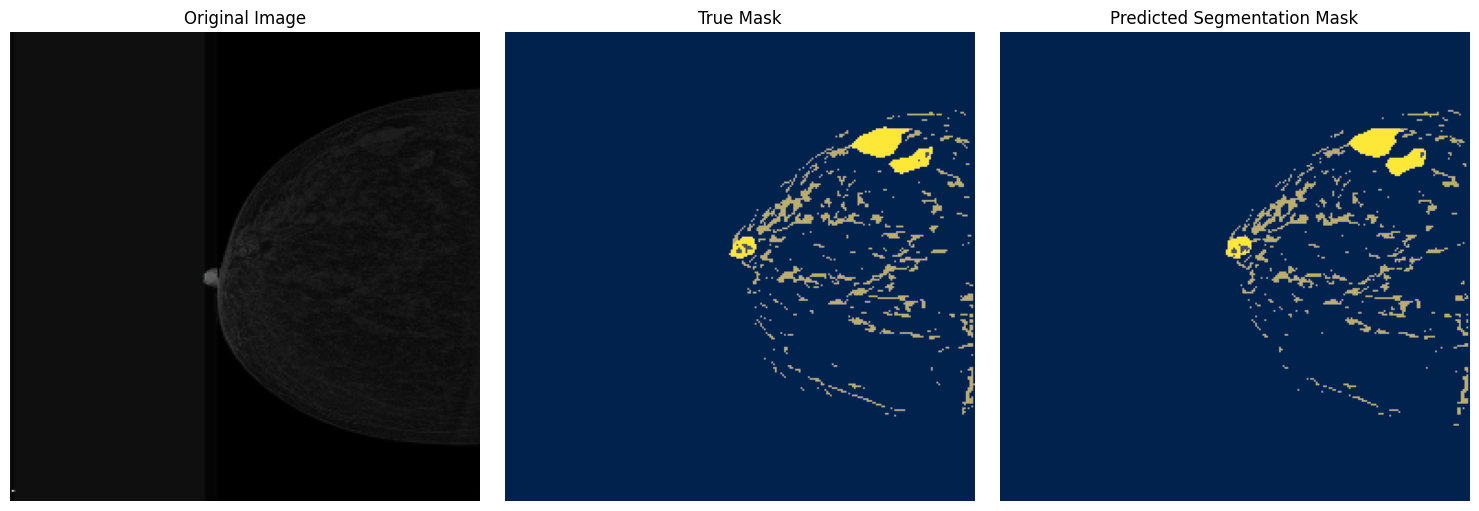

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step

Column: mass
True Label (Raw): 0
Predicted Label (Raw): 1

Column: mass_definition
True Label (Raw): 0
Predicted Label (Raw): 1

Column: mass_density
True Label (Raw): 0
Predicted Label (Raw): 1

Column: mass_shape
True Label (Raw): 0
Predicted Label (Raw): 3

Column: mass_calcification
True Label (Raw): 0
Predicted Label (Raw): 1

Column: axilla_findings
True Label (Raw): 1
Predicted Label (Raw): 0

Column: calcification
True Label (Raw): 0
Predicted Label (Raw): 1

Column: calcification_type
True Label (Raw): 0
Predicted Label (Raw): 2

Column: acr_breast_density
True Label (Raw): 2
Predicted Label (Raw): 2

Column: BIRADS_CAT
True Label (Raw): 2
Predicted Label (Raw): 3


In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Get a random batch index from the test generator
batch_index = np.random.randint(0, len(test_generator))

# Access the specific batch
test_images, test_masks = test_generator[batch_index]

# Choose a random index from the batch
random_index = np.random.randint(0, test_images.shape[0])

# Select the image and true mask using the random index
input_image = test_images[random_index]  # Shape: (height, width, channels)
true_mask = test_masks[random_index]    # Ground truth mask (one-hot encoded)

# Add batch dimension for prediction
input_image = np.expand_dims(input_image, axis=0)  # Shape: (1, height, width, channels)

# Predict the segmentation mask
predicted_mask = segmentation_model.predict(input_image)  # Shape: (1, height, width, num_classes)
predicted_mask = np.argmax(predicted_mask[0], axis=-1)  # Convert one-hot to class indices

# Extract features from the segmentation model
segmentation_features = feature_extractor.predict(input_image)  # Shape: (1, 16, 16, 512)
segmentation_features = segmentation_features.reshape(1, -1, 512).mean(axis=1)  # Apply Global Average Pooling
segmentation_features = scaler_seg.transform(segmentation_features)  # Normalize the features

# Plot the original image, true mask, and predicted mask
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(input_image[0].squeeze(), cmap='gray')  # Use 'gray' colormap for grayscale images
plt.axis('off')

# True Mask
plt.subplot(1, 3, 2)
plt.title("True Mask")
plt.imshow(np.argmax(true_mask, axis=-1), cmap='cividis')  # Convert one-hot to class indices
plt.axis('off')

# Predicted Mask
plt.subplot(1, 3, 3)
plt.title("Predicted Segmentation Mask")
plt.imshow(predicted_mask, cmap='cividis')  # Use 'cividis' colormap for segmentation masks
plt.axis('off')

plt.tight_layout()
plt.show()

# Predict tabular features using the tabular prediction model
predicted_tabular_features = tabular_prediction_model_raw.predict(segmentation_features)  # Dictionary of predictions

# Inspect predictions for each target variable
for col in target_columns:
    if output_dims[col] > 1:  # Skip constant variables
        print(f"\nColumn: {col}")
        
        # True labels (encoded)
        y_true_encoded = y_test_tabular[col][random_index]
        
        # Predictions (encoded)
        y_pred_col = predicted_tabular_features[col][0]  # Shape: (1,)
        
        if output_dims[col] == 2:  # Binary classification
            y_pred_encoded = 1 if y_pred_col > 0.5 else 0  # Threshold predictions
        else:  # Multi-class classification
            y_pred_encoded = np.argmax(y_pred_col)  # Get predicted class index
        
        # Map encoded values back to original raw values
        le = label_encoders[col]
        y_true_raw = le.inverse_transform([y_true_encoded])[0]  # True label in raw format
        y_pred_raw = le.inverse_transform([y_pred_encoded])[0]  # Predicted label in raw format
        
        # Print true and predicted labels in raw format
        print("True Label (Raw):", y_true_raw)
        print("Predicted Label (Raw):", y_pred_raw)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


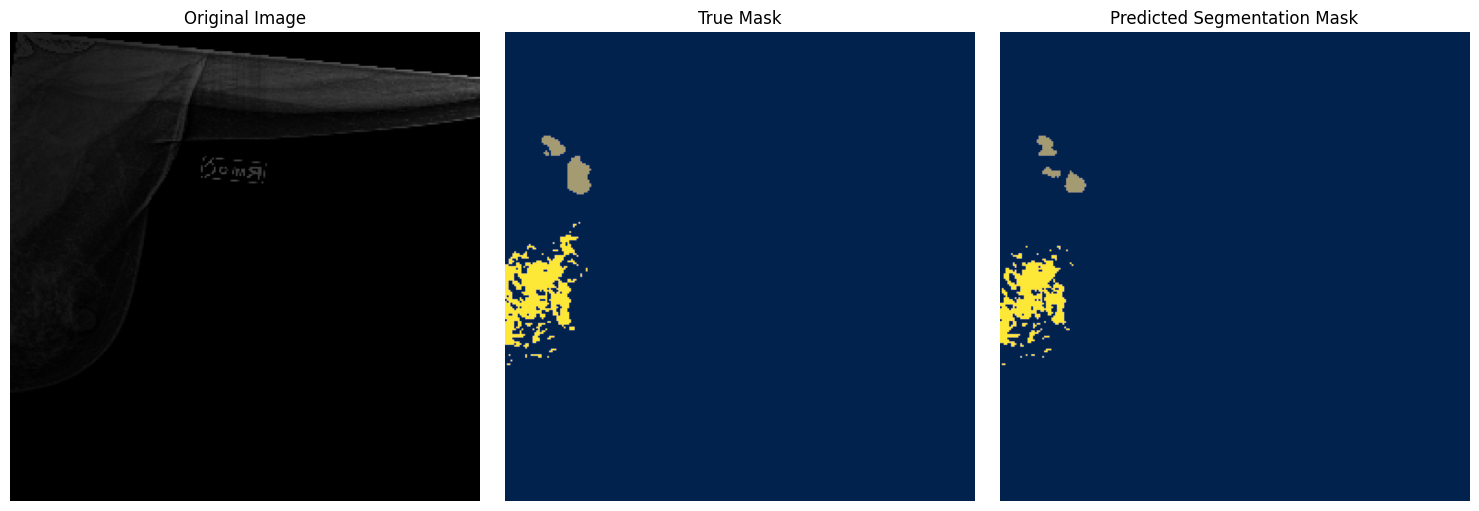

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Column: mass
True Label (Raw): 1
Predicted Label (Raw): 0

Column: mass_definition
True Label (Raw): 1
Predicted Label (Raw): 0

Column: mass_density
True Label (Raw): 1
Predicted Label (Raw): 0

Column: mass_shape
True Label (Raw): 3
Predicted Label (Raw): 0

Column: mass_calcification
True Label (Raw): 1
Predicted Label (Raw): 0

Column: axilla_findings
True Label (Raw): 0
Predicted Label (Raw): 1

Column: calcification
True Label (Raw): 1
Predicted Label (Raw): 0

Column: calcification_type
True Label (Raw): 1
Predicted Label (Raw): 0

Column: acr_breast_density
True Label (Raw): 3
Predicted Label (Raw): 2

Column: BIRADS_CAT
True Label (Raw): 4
Predicted Label (Raw): 1


In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Get a random batch index from the test generator
batch_index = np.random.randint(0, len(test_generator))

# Access the specific batch
test_images, test_masks = test_generator[batch_index]

# Choose a random index from the batch
random_index = np.random.randint(0, test_images.shape[0])

# Select the image and true mask using the random index
input_image = test_images[random_index]  # Shape: (height, width, channels)
true_mask = test_masks[random_index]    # Ground truth mask (one-hot encoded)

# Add batch dimension for prediction
input_image = np.expand_dims(input_image, axis=0)  # Shape: (1, height, width, channels)

# Predict the segmentation mask
predicted_mask = segmentation_model.predict(input_image)  # Shape: (1, height, width, num_classes)
predicted_mask = np.argmax(predicted_mask[0], axis=-1)  # Convert one-hot to class indices

# Extract features from the segmentation model
segmentation_features = feature_extractor.predict(input_image)  # Shape: (1, 16, 16, 512)
segmentation_features = segmentation_features.reshape(1, -1, 512).mean(axis=1)  # Apply Global Average Pooling
segmentation_features = scaler_seg.transform(segmentation_features)  # Normalize the features

# Plot the original image, true mask, and predicted mask
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(input_image[0].squeeze(), cmap='gray')  # Use 'gray' colormap for grayscale images
plt.axis('off')

# True Mask
plt.subplot(1, 3, 2)
plt.title("True Mask")
plt.imshow(np.argmax(true_mask, axis=-1), cmap='cividis')  # Convert one-hot to class indices
plt.axis('off')

# Predicted Mask
plt.subplot(1, 3, 3)
plt.title("Predicted Segmentation Mask")
plt.imshow(predicted_mask, cmap='cividis')  # Use 'cividis' colormap for segmentation masks
plt.axis('off')

plt.tight_layout()
plt.show()

# Predict tabular features using the tabular prediction model
predicted_tabular_features = tabular_prediction_model_raw.predict(segmentation_features)  # Dictionary of predictions

# Inspect predictions for each target variable
for col in target_columns:
    if output_dims[col] > 1:  # Skip constant variables
        print(f"\nColumn: {col}")
        
        # True labels (encoded)
        y_true_encoded = y_test_tabular[col][random_index]
        
        # Predictions (encoded)
        y_pred_col = predicted_tabular_features[col][0]  # Shape: (1,)
        
        if output_dims[col] == 2:  # Binary classification
            y_pred_encoded = 1 if y_pred_col > 0.5 else 0  # Threshold predictions
        else:  # Multi-class classification
            y_pred_encoded = np.argmax(y_pred_col)  # Get predicted class index
        
        # Map encoded values back to original raw values
        le = label_encoders[col]
        y_true_raw = le.inverse_transform([y_true_encoded])[0]  # True label in raw format
        y_pred_raw = le.inverse_transform([y_pred_encoded])[0]  # Predicted label in raw format
        
        # Print true and predicted labels in raw format
        print("True Label (Raw):", y_true_raw)
        print("Predicted Label (Raw):", y_pred_raw)

In [42]:
test_data.head()

,mass,mass_definition,mass_density,mass_shape,mass_calcification,axilla_findings,calcification,calcification_type,acr_breast_density,BIRADS_CAT
0,1,1,1,3,0,0,0,0,2,3
1,0,0,0,0,0,0,1,1,1,2
2,1,1,1,3,1,0,1,1,3,4
3,1,1,1,3,0,0,0,0,3,4
4,0,0,0,0,0,1,1,1,1,2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


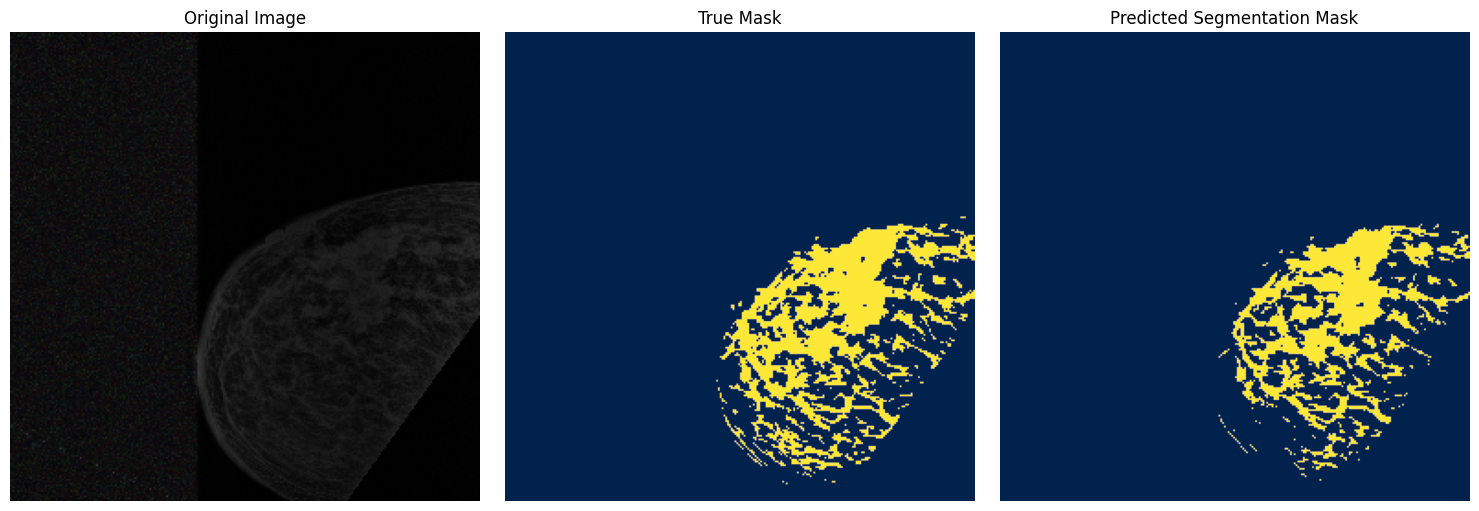

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Column: mass
True Label (Raw): 1
Predicted Label (Raw): 1

Column: mass_definition
True Label (Raw): 1
Predicted Label (Raw): 0

Column: mass_density
True Label (Raw): 1
Predicted Label (Raw): 1

Column: mass_shape
True Label (Raw): 3
Predicted Label (Raw): 3

Column: mass_calcification
True Label (Raw): 0
Predicted Label (Raw): 0

Column: axilla_findings
True Label (Raw): 0
Predicted Label (Raw): 0

Column: calcification
True Label (Raw): 0
Predicted Label (Raw): 0

Column: calcification_type
True Label (Raw): 0
Predicted Label (Raw): 0

Column: acr_breast_density
True Label (Raw): 3
Predicted Label (Raw): 3

Column: BIRADS_CAT
True Label (Raw): 4
Predicted Label (Raw): 3


In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Set the specific index you want to use
x = 3  # Replace 42 with your desired index

# Calculate the batch index and the index within the batch
batch_index = x // test_generator.batch_size
index_in_batch = x % test_generator.batch_size

# Access the specific batch
test_images, test_masks = test_generator[batch_index]

# Select the image and true mask using the specific index
input_image = test_images[index_in_batch]  # Shape: (height, width, channels)
true_mask = test_masks[index_in_batch]    # Ground truth mask (one-hot encoded)

# Add batch dimension for prediction
input_image = np.expand_dims(input_image, axis=0)  # Shape: (1, height, width, channels)

# Predict the segmentation mask
predicted_mask = segmentation_model.predict(input_image)  # Shape: (1, height, width, num_classes)
predicted_mask = np.argmax(predicted_mask[0], axis=-1)  # Convert one-hot to class indices

# Extract features from the segmentation model
segmentation_features = feature_extractor.predict(input_image)  # Shape: (1, 16, 16, 512)
segmentation_features = segmentation_features.reshape(1, -1, 512).mean(axis=1)  # Apply Global Average Pooling
segmentation_features = scaler_seg.transform(segmentation_features)  # Normalize the features

# Plot the original image, true mask, and predicted mask
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(input_image[0].squeeze(), cmap='gray')  # Use 'gray' colormap for grayscale images
plt.axis('off')

# True Mask
plt.subplot(1, 3, 2)
plt.title("True Mask")
plt.imshow(np.argmax(true_mask, axis=-1), cmap='cividis')  # Convert one-hot to class indices
plt.axis('off')

# Predicted Mask
plt.subplot(1, 3, 3)
plt.title("Predicted Segmentation Mask")
plt.imshow(predicted_mask, cmap='cividis')  # Use 'cividis' colormap for segmentation masks
plt.axis('off')

plt.tight_layout()
plt.show()

# Predict tabular features using the tabular prediction model
predicted_tabular_features = tabular_prediction_model_raw.predict(segmentation_features)  # Dictionary of predictions

# Inspect predictions for each target variable
for col in target_columns:
    if output_dims[col] > 1:  # Skip constant variables
        print(f"\nColumn: {col}")
        
        # True labels (encoded)
        y_true_encoded = y_test_tabular[col][x]
        
        # Predictions (encoded)
        y_pred_col = predicted_tabular_features[col][0]  # Shape: (1,)
        
        if output_dims[col] == 2:  # Binary classification
            y_pred_encoded = 1 if y_pred_col > 0.5 else 0  # Threshold predictions
        else:  # Multi-class classification
            y_pred_encoded = np.argmax(y_pred_col)  # Get predicted class index
        
        # Map encoded values back to original raw values
        le = label_encoders[col]
        y_true_raw = le.inverse_transform([y_true_encoded])[0]  # True label in raw format
        y_pred_raw = le.inverse_transform([y_pred_encoded])[0]  # Predicted label in raw format
        
        # Print true and predicted labels in raw format
        print("True Label (Raw):", y_true_raw)
        print("Predicted Label (Raw):", y_pred_raw)

In [87]:
print(dir(test_generator))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__next__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_api_export_path', '_api_export_symbol_id', '_max_queue_size', '_use_multiprocessing', '_warn_if_super_not_called', '_workers', 'batch_size', 'class_rgb_array', 'image_paths', 'image_size', 'label_encode_mask', 'mask_paths', 'max_queue_size', 'n_classes', 'num_batches', 'on_epoch_begin', 'on_epoch_end', 'use_multiprocessing', 'workers']


In [93]:
# Calculate the batch index and the index within the batch
batch_index = x // test_generator.batch_size
index_in_batch = x % test_generator.batch_size

# Access the specific batch
test_images, test_masks = test_generator[batch_index]

# Select the image and true mask using the specific index
input_image = test_images[index_in_batch]  # Shape: (height, width, channels)
true_mask = test_masks[index_in_batch]    # Ground truth mask (one-hot encoded)

# Print the image and mask paths for debugging
print(f"Image path: {test_generator.image_paths[x]}")
print(f"Mask path: {test_generator.mask_paths[x]}")

# Debugging: Check index mapping
batch_index = x // test_generator.batch_size
index_in_batch = x % test_generator.batch_size
print(f"Index in test_data: {x}")
print(f"Batch index: {batch_index}, Index in batch: {index_in_batch}")

# Debugging: Compare raw labels
print(f"True label from test_data: {test_data.iloc[x][col]}")
print(f"True label from test_generator: {true_mask}")

# Debugging: Check label encoding
print(f"Encoded true label: {y_true_encoded}")
print(f"Decoded true label: {y_true_raw}")

Image path: /kaggle/input/breast-multimodal-merged-aug-set-1-2-3-resized-256/images/IMG285_aug_181_1106.png
Mask path: /kaggle/input/breast-multimodal-merged-aug-set-1-2-3-resized-256/masks/IMG285_aug_181_1106.png
Index in test_data: 2
Batch index: 0, Index in batch: 2
True label from test_data: 4
True label from test_generator: [[[1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  ...
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  ...
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  ...
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]]

 ...

 [[1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  ...
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  ...
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]]

 [[1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0.]
  [1. 0. 0. 0. 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


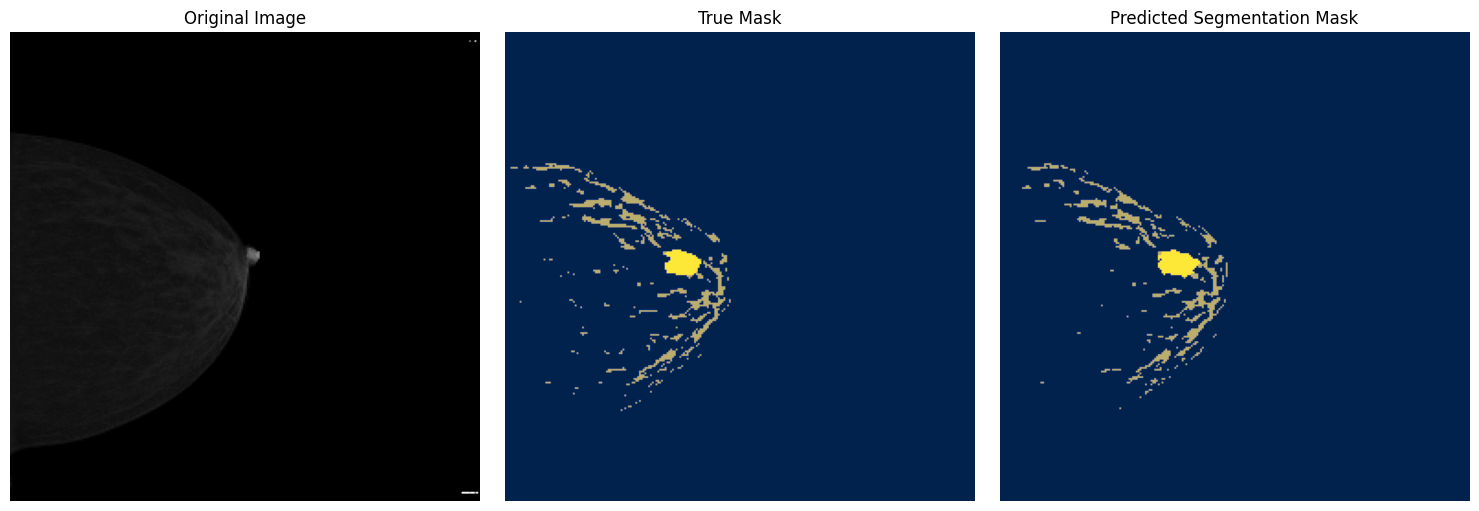

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Column: mass
True Label (Raw): 1
Predicted Label (Raw): 1

Column: mass_definition
True Label (Raw): 1
Predicted Label (Raw): 2

Column: mass_density
True Label (Raw): 1
Predicted Label (Raw): 1

Column: mass_shape
True Label (Raw): 3
Predicted Label (Raw): 3

Column: mass_calcification
True Label (Raw): 0
Predicted Label (Raw): 0

Column: axilla_findings
True Label (Raw): 0
Predicted Label (Raw): 0

Column: calcification
True Label (Raw): 0
Predicted Label (Raw): 0

Column: calcification_type
True Label (Raw): 0
Predicted Label (Raw): 0

Column: acr_breast_density
True Label (Raw): 2
Predicted Label (Raw): 2

Column: BIRADS_CAT
True Label (Raw): 3
Predicted Label (Raw): 4


In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Set the specific index you want to use
x = 0  # Replace 2 with your desired index

# Calculate the batch index and the index within the batch
batch_index = x // test_generator.batch_size
index_in_batch = x % test_generator.batch_size

# Access the specific batch
test_images, test_masks = test_generator[batch_index]

# Select the image and true mask using the specific index
input_image = test_images[index_in_batch]  # Shape: (height, width, channels)
true_mask = test_masks[index_in_batch]    # Ground truth mask (one-hot encoded)

# Add batch dimension for prediction
input_image = np.expand_dims(input_image, axis=0)  # Shape: (1, height, width, channels)

# Predict the segmentation mask
predicted_mask = segmentation_model.predict(input_image)  # Shape: (1, height, width, num_classes)
predicted_mask = np.argmax(predicted_mask[0], axis=-1)  # Convert one-hot to class indices

# Extract features from the segmentation model
segmentation_features = feature_extractor.predict(input_image)  # Shape: (1, 16, 16, 512)
segmentation_features = segmentation_features.reshape(1, -1, 512).mean(axis=1)  # Apply Global Average Pooling
segmentation_features = scaler_seg.transform(segmentation_features)  # Normalize the features

# Plot the original image, true mask, and predicted mask
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(input_image[0].squeeze(), cmap='gray')  # Use 'gray' colormap for grayscale images
plt.axis('off')

# True Mask
plt.subplot(1, 3, 2)
plt.title("True Mask")
plt.imshow(np.argmax(true_mask, axis=-1), cmap='cividis')  # Convert one-hot to class indices
plt.axis('off')

# Predicted Mask
plt.subplot(1, 3, 3)
plt.title("Predicted Segmentation Mask")
plt.imshow(predicted_mask, cmap='cividis')  # Use 'cividis' colormap for segmentation masks
plt.axis('off')

plt.tight_layout()
plt.show()

# Predict tabular features using the tabular prediction model
predicted_tabular_features = tabular_prediction_model_raw.predict(segmentation_features)  # Dictionary of predictions

# Inspect predictions for each target variable
for col in target_columns:
    if output_dims[col] > 1:  # Skip constant variables
        print(f"\nColumn: {col}")
        
        # True labels (encoded)
        y_true_encoded = y_test_tabular[col][x]
        
        # Predictions (encoded)
        y_pred_col = predicted_tabular_features[col][0]  # Shape: (1,)
        
        if output_dims[col] == 2:  # Binary classification
            y_pred_encoded = 1 if y_pred_col > 0.5 else 0  # Threshold predictions
        else:  # Multi-class classification
            y_pred_encoded = np.argmax(y_pred_col)  # Get predicted class index
        
        # Map encoded values back to original raw values
        le = label_encoders[col]
        y_true_raw = le.inverse_transform([y_true_encoded])[0]  # True label in raw format
        y_pred_raw = le.inverse_transform([y_pred_encoded])[0]  # Predicted label in raw format
        
        # Print true and predicted labels in raw format
        print("True Label (Raw):", y_true_raw)
        print("Predicted Label (Raw):", y_pred_raw)

File path for the selected image: /kaggle/input/breast-multimodal-merged-aug-set-1-2-3-resized-256/images/IMG318_aug_154_1721.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


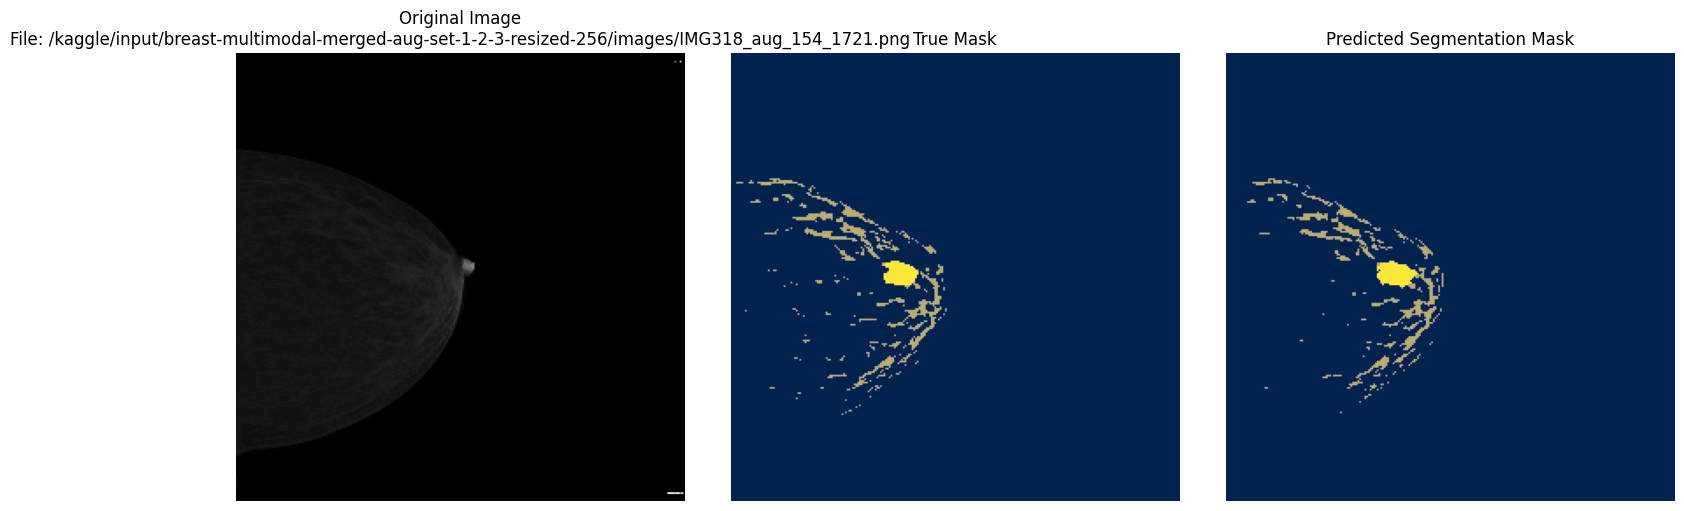

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Column: mass
True Label (Raw): 1
Predicted Label (Raw): 1

Column: mass_definition
True Label (Raw): 1
Predicted Label (Raw): 2

Column: mass_density
True Label (Raw): 1
Predicted Label (Raw): 1

Column: mass_shape
True Label (Raw): 3
Predicted Label (Raw): 3

Column: mass_calcification
True Label (Raw): 0
Predicted Label (Raw): 0

Column: axilla_findings
True Label (Raw): 0
Predicted Label (Raw): 0

Column: calcification
True Label (Raw): 0
Predicted Label (Raw): 0

Column: calcification_type
True Label (Raw): 0
Predicted Label (Raw): 0

Column: acr_breast_density
True Label (Raw): 2
Predicted Label (Raw): 2

Column: BIRADS_CAT
True Label (Raw): 3
Predicted Label (Raw): 4


In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Set the specific index you want to use
x = 0  # Replace 0 with your desired index

# Calculate the batch index and the index within the batch
batch_index = x // test_generator.batch_size
index_in_batch = x % test_generator.batch_size

# Access the specific batch
test_images, test_masks = test_generator[batch_index]

# Select the image and true mask using the specific index
input_image = test_images[index_in_batch]  # Shape: (height, width, channels)
true_mask = test_masks[index_in_batch]    # Ground truth mask (one-hot encoded)

# Get the file path for the selected image
file_path = test_generator.image_paths[x]  # Access the file path from image_paths
print(f"File path for the selected image: {file_path}")

# Add batch dimension for prediction
input_image = np.expand_dims(input_image, axis=0)  # Shape: (1, height, width, channels)

# Predict the segmentation mask
predicted_mask = segmentation_model.predict(input_image)  # Shape: (1, height, width, num_classes)
predicted_mask = np.argmax(predicted_mask[0], axis=-1)  # Convert one-hot to class indices

# Extract features from the segmentation model
segmentation_features = feature_extractor.predict(input_image)  # Shape: (1, 16, 16, 512)
segmentation_features = segmentation_features.reshape(1, -1, 512).mean(axis=1)  # Apply Global Average Pooling
segmentation_features = scaler_seg.transform(segmentation_features)  # Normalize the features

# Plot the original image, true mask, and predicted mask
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.title(f"Original Image\nFile: {file_path}")  # Include file path in the title
plt.imshow(input_image[0].squeeze(), cmap='gray')  # Use 'gray' colormap for grayscale images
plt.axis('off')

# True Mask
plt.subplot(1, 3, 2)
plt.title("True Mask")
plt.imshow(np.argmax(true_mask, axis=-1), cmap='cividis')  # Convert one-hot to class indices
plt.axis('off')

# Predicted Mask
plt.subplot(1, 3, 3)
plt.title("Predicted Segmentation Mask")
plt.imshow(predicted_mask, cmap='cividis')  # Use 'cividis' colormap for segmentation masks
plt.axis('off')

plt.tight_layout()
plt.show()

# Predict tabular features using the tabular prediction model
predicted_tabular_features = tabular_prediction_model_raw.predict(segmentation_features)  # Dictionary of predictions

# Inspect predictions for each target variable
for col in target_columns:
    if output_dims[col] > 1:  # Skip constant variables
        print(f"\nColumn: {col}")
        
        # True labels (encoded)
        y_true_encoded = y_test_tabular[col][x]
        
        # Predictions (encoded)
        y_pred_col = predicted_tabular_features[col][0]  # Shape: (1,)
        
        if output_dims[col] == 2:  # Binary classification
            y_pred_encoded = 1 if y_pred_col > 0.5 else 0  # Threshold predictions
        else:  # Multi-class classification
            y_pred_encoded = np.argmax(y_pred_col)  # Get predicted class index
        
        # Map encoded values back to original raw values
        le = label_encoders[col]
        y_true_raw = le.inverse_transform([y_true_encoded])[0]  # True label in raw format
        y_pred_raw = le.inverse_transform([y_pred_encoded])[0]  # Predicted label in raw format
        
        # Print true and predicted labels in raw format
        print("True Label (Raw):", y_true_raw)
        print("Predicted Label (Raw):", y_pred_raw)

Random index selected: 9
File path for the selected image: /kaggle/input/breast-multimodal-merged-aug-set-1-2-3-resized-256/images/2401052405_240123_BREAST_0194_AH06421999.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


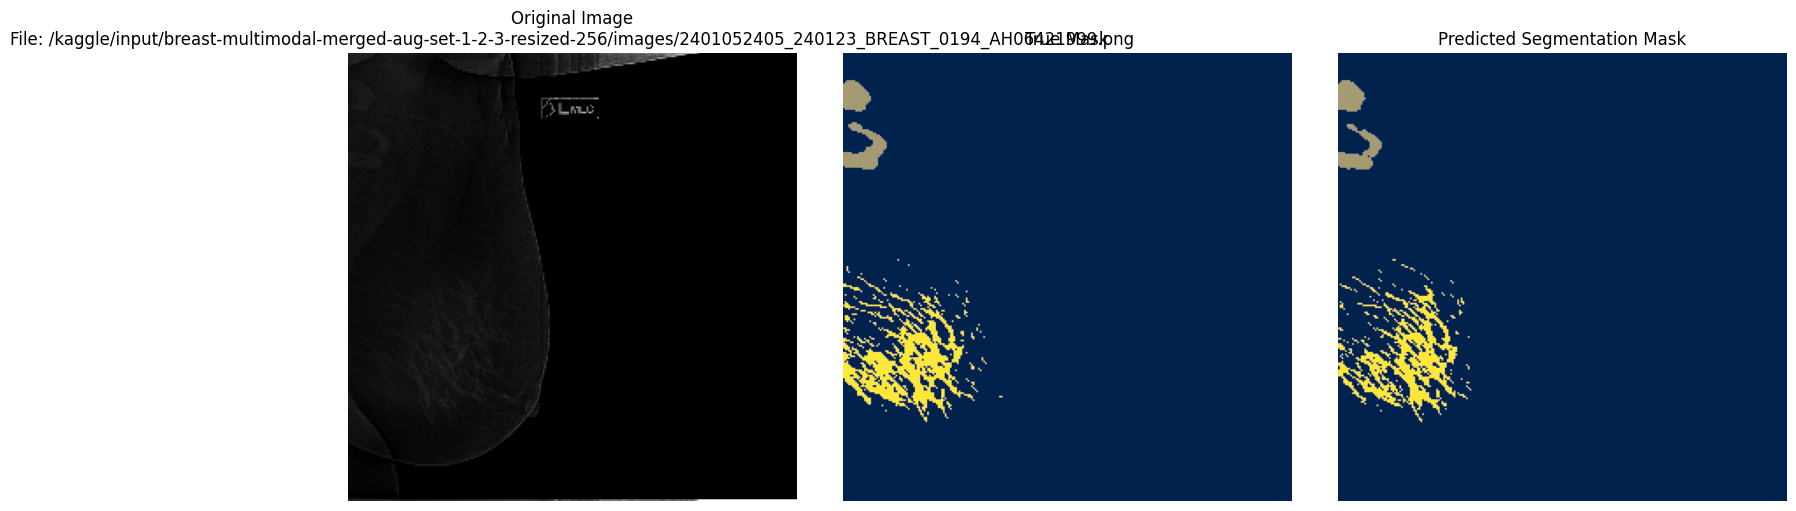

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Column: mass
True Label (Raw): 0
Predicted Label (Raw): 0

Column: mass_definition
True Label (Raw): 0
Predicted Label (Raw): 0

Column: mass_density
True Label (Raw): 0
Predicted Label (Raw): 0

Column: mass_shape
True Label (Raw): 0
Predicted Label (Raw): 0

Column: mass_calcification
True Label (Raw): 0
Predicted Label (Raw): 0

Column: axilla_findings
True Label (Raw): 1
Predicted Label (Raw): 1

Column: calcification
True Label (Raw): 0
Predicted Label (Raw): 0

Column: calcification_type
True Label (Raw): 0
Predicted Label (Raw): 0

Column: acr_breast_density
True Label (Raw): 1
Predicted Label (Raw): 1

Column: BIRADS_CAT
True Label (Raw): 6
Predicted Label (Raw): 1


In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Generate a random index within the range of the dataset
random_index = np.random.randint(0, len(test_generator.image_paths))  # Random index
print(f"Random index selected: {random_index}")

# Calculate the batch index and the index within the batch
batch_index = random_index // test_generator.batch_size
index_in_batch = random_index % test_generator.batch_size

# Access the specific batch
test_images, test_masks = test_generator[batch_index]

# Select the image and true mask using the random index
input_image = test_images[index_in_batch]  # Shape: (height, width, channels)
true_mask = test_masks[index_in_batch]    # Ground truth mask (one-hot encoded)

# Get the file path for the selected image
file_path = test_generator.image_paths[random_index]  # Access the file path from image_paths
print(f"File path for the selected image: {file_path}")

# Add batch dimension for prediction
input_image = np.expand_dims(input_image, axis=0)  # Shape: (1, height, width, channels)

# Predict the segmentation mask
predicted_mask = segmentation_model.predict(input_image)  # Shape: (1, height, width, num_classes)
predicted_mask = np.argmax(predicted_mask[0], axis=-1)  # Convert one-hot to class indices

# Extract features from the segmentation model
segmentation_features = feature_extractor.predict(input_image)  # Shape: (1, 16, 16, 512)
segmentation_features = segmentation_features.reshape(1, -1, 512).mean(axis=1)  # Apply Global Average Pooling
segmentation_features = scaler_seg.transform(segmentation_features)  # Normalize the features

# Plot the original image, true mask, and predicted mask
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.title(f"Original Image\nFile: {file_path}")  # Include file path in the title
plt.imshow(input_image[0].squeeze(), cmap='gray')  # Use 'gray' colormap for grayscale images
plt.axis('off')

# True Mask
plt.subplot(1, 3, 2)
plt.title("True Mask")
plt.imshow(np.argmax(true_mask, axis=-1), cmap='cividis')  # Convert one-hot to class indices
plt.axis('off')

# Predicted Mask
plt.subplot(1, 3, 3)
plt.title("Predicted Segmentation Mask")
plt.imshow(predicted_mask, cmap='cividis')  # Use 'cividis' colormap for segmentation masks
plt.axis('off')

plt.tight_layout()
plt.show()

# Predict tabular features using the tabular prediction model
predicted_tabular_features = tabular_prediction_model_raw.predict(segmentation_features)  # Dictionary of predictions

# Inspect predictions for each target variable
for col in target_columns:
    if output_dims[col] > 1:  # Skip constant variables
        print(f"\nColumn: {col}")
        
        # True labels (encoded)
        y_true_encoded = y_test_tabular[col][random_index]
        
        # Predictions (encoded)
        y_pred_col = predicted_tabular_features[col][0]  # Shape: (1,)
        
        if output_dims[col] == 2:  # Binary classification
            y_pred_encoded = 1 if y_pred_col > 0.5 else 0  # Threshold predictions
        else:  # Multi-class classification
            y_pred_encoded = np.argmax(y_pred_col)  # Get predicted class index
        
        # Map encoded values back to original raw values
        le = label_encoders[col]
        y_true_raw = le.inverse_transform([y_true_encoded])[0]  # True label in raw format
        y_pred_raw = le.inverse_transform([y_pred_encoded])[0]  # Predicted label in raw format
        
        # Print true and predicted labels in raw format
        print("True Label (Raw):", y_true_raw)
        print("Predicted Label (Raw):", y_pred_raw)

In [ ]:
train_features = feature_extractor.predict(train_generator)
train_features = train_features.reshape(len(train_features), -1, 512).mean(axis=1)
scaler_seg = StandardScaler()
scaler_seg.fit(train_features)
with open("H:/Research/Breast Cancer/scaler.pkl", "wb") as f:
    pickle.dump(scaler_seg, f)


def extract_and_scale_features(image_normalized, scaler_path="H:/Research/Breast Cancer/scaler.pkl"):
    features = feature_extractor.predict(image_normalized)
    features = features.reshape(1, -1, 512).mean(axis=1)
    with open(scaler_path, "rb") as f:
        scaler_seg = pickle.load(f)
    return scaler_seg.transform(features)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler_seg, f)
for col in target_columns:
    with open(f"{col}_label_encoder.pkl", "wb") as f:
        pickle.dump(label_encoders[col], f)
tabular_prediction_model_raw.save("tabular_model.h5")